In [1]:
!pip install ray

In [2]:
# 주의! ray를 pytorch보다 먼저 import하면 오류가 발생할 수 있습니다
import io, json, os, math

import torch
import torch.nn as nn
import torch.nn.functional as F

import ray

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# 프로젝트 경로 설정
PROJECT_PATH = os.path.join(os.getenv("HOME"), 'work/mpii')
IMAGE_PATH = os.path.join(PROJECT_PATH, 'images')
MODEL_PATH = os.path.join(PROJECT_PATH, 'models')
PT_RECORD_PATH = os.path.join(PROJECT_PATH, 'ptrecords_mpii')
TRAIN_JSON = os.path.join(PROJECT_PATH, 'mpii_human_pose_v1_u12_2', 'train.json')
VALID_JSON = os.path.join(PROJECT_PATH, 'mpii_human_pose_v1_u12_2', 'validation.json')

In [3]:
with open(TRAIN_JSON) as train_json:
    train_annos = json.load(train_json)
    json_formatted_str = json.dumps(train_annos[0], indent=2)
    print(json_formatted_str)

{
  "joints_vis": [
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1
  ],
  "joints": [
    [
      620.0,
      394.0
    ],
    [
      616.0,
      269.0
    ],
    [
      573.0,
      185.0
    ],
    [
      647.0,
      188.0
    ],
    [
      661.0,
      221.0
    ],
    [
      656.0,
      231.0
    ],
    [
      610.0,
      187.0
    ],
    [
      647.0,
      176.0
    ],
    [
      637.0201,
      189.8183
    ],
    [
      695.9799,
      108.1817
    ],
    [
      606.0,
      217.0
    ],
    [
      553.0,
      161.0
    ],
    [
      601.0,
      167.0
    ],
    [
      692.0,
      185.0
    ],
    [
      693.0,
      240.0
    ],
    [
      688.0,
      313.0
    ]
  ],
  "image": "015601864.jpg",
  "scale": 3.021046,
  "center": [
    594.0,
    257.0
  ]
}


In [4]:
def parse_one_annotation(anno, image_dir):
    filename = anno['image']
    joints = anno['joints']
    joints_visibility = anno['joints_vis']
    annotation = {
        'filename': filename,
        'filepath': os.path.join(image_dir, filename),
        'joints_visibility': joints_visibility,
        'joints': joints,
        'center': anno['center'],
        'scale' : anno['scale']
    }
    return annotation

In [5]:
with open(TRAIN_JSON) as train_json:
    train_annos = json.load(train_json)
    test = parse_one_annotation(train_annos[0], IMAGE_PATH)
    print(test)

{'filename': '015601864.jpg', 'filepath': '/home/jovyan/work/mpii/images/015601864.jpg', 'joints_visibility': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'joints': [[620.0, 394.0], [616.0, 269.0], [573.0, 185.0], [647.0, 188.0], [661.0, 221.0], [656.0, 231.0], [610.0, 187.0], [647.0, 176.0], [637.0201, 189.8183], [695.9799, 108.1817], [606.0, 217.0], [553.0, 161.0], [601.0, 167.0], [692.0, 185.0], [693.0, 240.0], [688.0, 313.0]], 'center': [594.0, 257.0], 'scale': 3.021046}


In [6]:
def generate_ptexample(anno):
    filename = anno['filename']
    filepath = anno['filepath']

    # 이미지 파일 읽기
    with open(filepath, 'rb') as image_file:
        content = image_file.read()

    image = Image.open(filepath)
    # JPEG 형식 및 RGB 모드가 아니면 변환
    if image.format != 'JPEG' or image.mode != 'RGB':
        image_rgb = image.convert('RGB')
        with io.BytesIO() as output:
            image_rgb.save(output, format="JPEG", quality=95)
            content = output.getvalue()

    width, height = image.size
    depth = 3

    c_x = int(anno['center'][0])
    c_y = int(anno['center'][1])
    scale = anno['scale']

    x = [int(joint[0]) if joint[0] >= 0 else int(joint[0])
         for joint in anno['joints']]
    y = [int(joint[1]) if joint[1] >= 0 else int(joint[0])
         for joint in anno['joints']]

    v = [0 if joint_v == 0 else 2 for joint_v in anno['joints_visibility']]

    feature = {
        'image/height': height,
        'image/width': width,
        'image/depth': depth,
        'image/object/parts/x': x,
        'image/object/parts/y': y,
        'image/object/center/x': c_x,
        'image/object/center/y': c_y,
        'image/object/scale': scale,
        'image/object/parts/v': v,
        'image/encoded': content,
        'image/filename': filename.encode()  # bytes로 저장
    }

    return feature

In [7]:
def chunkify(l, n): #sharding
    size = len(l) // n
    start = 0
    results = []
    for i in range(n):
        results.append(l[start:start + size])
        start += size
    return results

In [8]:
test_chunks = chunkify([0] * 1000, 64)
print(test_chunks)
print(len(test_chunks))
print(len(test_chunks[0]))

[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0,

In [9]:
import pickle

@ray.remote
def build_single_ptrecord(chunk, path):
    print('start to build ptrecord for ' + path)

    with open(path, 'wb') as writer:
        for anno in chunk:
            ptexample = generate_ptexample(anno)
            pickle.dump(ptexample, writer)

    print('finished building ptrecord for ' + path)

In [10]:
def build_pt_records(annotations, total_shards, split):
    chunks = chunkify(annotations, total_shards)
    futures = [
        build_single_ptrecord.remote(
            chunk, '{}/{}_{}_of_{}.ptrecords'.format(
                PT_RECORD_PATH,
                split,
                str(i + 1).zfill(4),
                str(total_shards).zfill(4),
            )
        ) for i, chunk in enumerate(chunks)
    ]
    ray.get(futures)

In [11]:
from torch.utils.data import Dataset

class MPIIDataset(Dataset):
    def __init__(self, annotation_file, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform

        # JSON 파일을 읽어 annotations 리스트 생성
        with open(annotation_file, 'r') as f:
            annotations = json.load(f)

        # 각 annotation을 파싱하여 리스트에 저장
        self.annotations = [parse_one_annotation(anno, image_dir) for anno in annotations]

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        anno = self.annotations[idx]
        # 이미지 파일 경로로부터 이미지를 로드 (RGB 모드로 변환)
        image = Image.open(anno['filepath']).convert('RGB')

        # transform이 있으면 적용
        if self.transform:
            image, heatmaps = self.transform({'image': image, 'annotation': anno})
            return image, heatmaps
        else:
            # transform이 없으면 원본 이미지와 annotation dict 반환
            return image, anno

In [12]:
%%time
num_train_shards = 64
num_val_shards = 8

ray.init()

print('Start to parse annotations.')
if not os.path.exists(PT_RECORD_PATH):
    os.makedirs(PT_RECORD_PATH)

with open(TRAIN_JSON) as train_json:
    train_annos = json.load(train_json)
    train_annotations = [
        parse_one_annotation(anno, IMAGE_PATH)
        for anno in train_annos
    ]
    print('First train annotation: ', train_annotations[0])

with open(VALID_JSON) as val_json:
    val_annos = json.load(val_json)
    val_annotations = [
        parse_one_annotation(anno, IMAGE_PATH)
        for anno in val_annos
    ]
    print('First val annotation: ', val_annotations[0])

print('Start to build PT Records.')
build_pt_records(train_annotations, num_train_shards, 'train')
build_pt_records(val_annotations, num_val_shards, 'val')

print('Successfully wrote {} annotations to PT Records.'.format(
    len(train_annotations) + len(val_annotations)))

2025-09-22 09:07:24,223	WARNING services.py:2148 -- WARNING: The object store is using /tmp instead of /dev/shm because /dev/shm has only 67108864 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=4.77gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.
2025-09-22 09:07:25,394	INFO worker.py:1951 -- Started a local Ray instance.


Start to parse annotations.
First train annotation:  {'filename': '015601864.jpg', 'filepath': '/home/jovyan/work/mpii/images/015601864.jpg', 'joints_visibility': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'joints': [[620.0, 394.0], [616.0, 269.0], [573.0, 185.0], [647.0, 188.0], [661.0, 221.0], [656.0, 231.0], [610.0, 187.0], [647.0, 176.0], [637.0201, 189.8183], [695.9799, 108.1817], [606.0, 217.0], [553.0, 161.0], [601.0, 167.0], [692.0, 185.0], [693.0, 240.0], [688.0, 313.0]], 'center': [594.0, 257.0], 'scale': 3.021046}
First val annotation:  {'filename': '005808361.jpg', 'filepath': '/home/jovyan/work/mpii/images/005808361.jpg', 'joints_visibility': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'joints': [[804.0, 711.0], [816.0, 510.0], [908.0, 438.0], [1040.0, 454.0], [906.0, 528.0], [883.0, 707.0], [974.0, 446.0], [985.0, 253.0], [982.7591, 235.9694], [962.2409, 80.0306], [869.0, 214.0], [798.0, 340.0], [902.0, 253.0], [1067.0, 253.0], [1167.0, 353.0], [1142.0, 478.0

In [13]:
!pip install tfrecord

In [14]:
from tfrecord.torch.dataset import TFRecordDataset

feature_description = {
    'image/height': 'int',
    'image/width': 'int',
    'image/depth': 'int',
    'image/object/parts/x': 'int',
    'image/object/parts/y': 'int',
    'image/object/parts/v': 'int',
    'image/object/center/x': 'int',
    'image/object/center/y': 'int',
    'image/object/scale': 'float',
    'image/encoded': 'byte',
    'image/filename': 'byte',
}

In [15]:
import torch

def crop_roi(image, features, margin=0.2):
    img_height, img_width, img_depth = image.shape

    keypoint_x = torch.tensor(features['image/object/parts/x'], dtype=torch.int32)
    keypoint_y = torch.tensor(features['image/object/parts/y'], dtype=torch.int32)
    center_x = features['image/object/center/x']
    center_y = features['image/object/center/y']
    body_height = features['image/object/scale'] * 200.0

    # 유효한 keypoint (값이 0보다 큰 값)만 선택합니다.
    masked_keypoint_x = keypoint_x[keypoint_x > 0]
    masked_keypoint_y = keypoint_y[keypoint_y > 0]

    # 최소, 최대 값 계산 (유효한 keypoint가 하나 이상 있다고 가정)
    keypoint_xmin = masked_keypoint_x.min()
    keypoint_xmax = masked_keypoint_x.max()
    keypoint_ymin = masked_keypoint_y.min()
    keypoint_ymax = masked_keypoint_y.max()

    # margin을 적용하여 경계를 확장 (body_height * margin 값을 정수로 캐스팅)
    extra = int(body_height * margin)
    xmin = int(keypoint_xmin.item()) - extra
    xmax = int(keypoint_xmax.item()) + extra
    ymin = int(keypoint_ymin.item()) - extra
    ymax = int(keypoint_ymax.item()) + extra

    # 이미지 경계를 벗어나지 않도록 조정
    effective_xmin = xmin if xmin > 0 else 0
    effective_ymin = ymin if ymin > 0 else 0
    effective_xmax = xmax if xmax < img_width else img_width
    effective_ymax = ymax if ymax < img_height else img_height

    # 이미지 크기 재조정
    cropped_image = image[effective_ymin:effective_ymax, effective_xmin:effective_xmax, :]
    new_height, new_width, _ = cropped_image.shape

    # keypoint 좌표를 정규화 (0~1 범위)
    effective_keypoint_x = (keypoint_x.float() - effective_xmin) / new_width
    effective_keypoint_y = (keypoint_y.float() - effective_ymin) / new_height

    return cropped_image, effective_keypoint_x, effective_keypoint_y

In [16]:
import torch

def generate_2d_gaussian(height, width, y0, x0, visibility=2, sigma=1, scale=12):
    # (height, width) 크기의 0으로 채워진 heatmap 생성
    heatmap = torch.zeros((height, width), dtype=torch.float32)

    xmin = x0 - 3 * sigma
    ymin = y0 - 3 * sigma
    xmax = x0 + 3 * sigma
    ymax = y0 + 3 * sigma

    # 범위가 이미지 내에 없거나, visibility가 0이면 heatmap 그대로 반환
    if xmin >= width or ymin >= height or xmax < 0 or ymax < 0 or visibility == 0:
        return heatmap

    size = int(6 * sigma + 1)
    grid_range = torch.arange(0, size, dtype=torch.float32)
    x_grid, y_grid = torch.meshgrid(grid_range, grid_range, indexing='xy')
    center_x = size // 2
    center_y = size // 2

    # 가우시안 patch 계산
    gaussian_patch = torch.exp(-(((x_grid - center_x)**2 + (y_grid - center_y)**2) / (sigma**2 * 2))) * scale

    # 이미지와 patch 간의 겹치는 영역 계산
    patch_xmin = max(0, -xmin)
    patch_ymin = max(0, -ymin)
    patch_xmax = min(xmax, width) - xmin
    patch_ymax = min(ymax, height) - ymin

    heatmap_xmin = max(0, xmin)
    heatmap_ymin = max(0, ymin)
    heatmap_xmax = min(xmax, width)
    heatmap_ymax = min(ymax, height)

    # 계산된 영역에 gaussian_patch 값을 할당
    heatmap[heatmap_ymin:heatmap_ymax, heatmap_xmin:heatmap_xmax] = \
        gaussian_patch[int(patch_ymin):int(patch_ymax), int(patch_xmin):int(patch_xmax)]

    return heatmap

def make_heatmaps(features, keypoint_x, keypoint_y, heatmap_shape):
    v = torch.tensor(features['image/object/parts/v'], dtype=torch.float32)
    x = torch.round(torch.tensor(keypoint_x, dtype=torch.float32) * heatmap_shape[0]).to(torch.int32)
    y = torch.round(torch.tensor(keypoint_y, dtype=torch.float32) * heatmap_shape[1]).to(torch.int32)

    num_heatmap = heatmap_shape[2]
    heatmaps_list = []
    for i in range(num_heatmap):
        # generate_2d_gaussian 함수 호출 시, height=heatmap_shape[1], width=heatmap_shape[0]
        gaussian = generate_2d_gaussian(
            heatmap_shape[1],
            heatmap_shape[0],
            int(y[i].item()),
            int(x[i].item()),
            visibility=int(v[i].item())
        )
        heatmaps_list.append(gaussian)

    # (num_heatmap, height, width) 텐서를 생성한 후, (height, width, num_heatmap)로 전치
    heatmaps = torch.stack(heatmaps_list, dim=0)
    heatmaps = heatmaps.permute(1, 2, 0)

    return heatmaps

In [17]:
import torch
from PIL import Image
import io
import numpy as np

class Preprocessor(object):
    def __init__(self,
                 image_shape=(256, 256, 3),
                 heatmap_shape=(64, 64, 16),
                 is_train=False):
        self.is_train = is_train
        self.image_shape = image_shape      # (height, width, channels)
        self.heatmap_shape = heatmap_shape  # (height, width, num_heatmap)

    def __call__(self, example):
        features = self.parse_tfexample(example)
        # image 데이터를 다시 bytes로 디코딩 후 재로딩 (JPEG 형식)
        image = Image.open(io.BytesIO(features['image/encoded']))

        if self.is_train:
            # 0.1 ~ 0.3 사이의 random margin 생성
            random_margin = torch.empty(1).uniform_(0.1, 0.3).item()
            image, keypoint_x, keypoint_y = self.crop_roi(image, features, margin=random_margin)
            image = image.resize((self.image_shape[1], self.image_shape[0]))
        else:
            image, keypoint_x, keypoint_y = self.crop_roi(image, features)
            image = image.resize((self.image_shape[1], self.image_shape[0]))

        # 이미지 정규화: uint8 → [0,255] → [-1, 1]
        image_np = np.array(image).astype(np.float32)
        image_np = image_np / 127.5 - 1.0
        # 채널 우선순서로 변환: (H, W, C) -> (C, H, W)
        image_tensor = torch.from_numpy(image_np).permute(2, 0, 1)

        heatmaps = self.make_heatmaps(features, keypoint_x, keypoint_y, self.heatmap_shape)

        return image_tensor, heatmaps

    def parse_tfexample(self, example):
        """
        MPIIDataset에서 전달한 예제를 받아, Preprocessor가 처리할 수 있도록 features dict를 구성합니다.
        예제 형식: {'image': PIL.Image, 'annotation': anno}
        """
        annotation = example['annotation']
        # joints: list of [x, y]
        joints = annotation['joints']
        keypoint_x = [joint[0] for joint in joints]
        keypoint_y = [joint[1] for joint in joints]

        # joints_vis가 없으면 모든 관절이 가시적이라고 가정 (1)
        joints_vis = annotation.get('joints_vis', [1] * len(joints))

        features = {
            'image/encoded': self.image_to_bytes(example['image']),
            'image/object/parts/x': keypoint_x,
            'image/object/parts/y': keypoint_y,
            'image/object/parts/v': joints_vis,
            'image/object/center/x': annotation['center'][0],
            'image/object/center/y': annotation['center'][1],
            'image/object/scale': annotation['scale'],
        }
        return features

    def image_to_bytes(self, image):
        """
        PIL.Image 객체를 JPEG 인코딩된 bytes로 변환합니다.
        """
        buffer = io.BytesIO()
        image.save(buffer, format="JPEG")
        return buffer.getvalue()

    def crop_roi(self, image, features, margin=0.2):
        # image: PIL.Image, features: dict
        img_width, img_height = image.size  # PIL: (width, height)

        keypoint_x = torch.tensor(features['image/object/parts/x'], dtype=torch.int32)
        keypoint_y = torch.tensor(features['image/object/parts/y'], dtype=torch.int32)
        body_height = features['image/object/scale'] * 200.0

        # 유효한 keypoint (값 > 0)만 선택
        masked_keypoint_x = keypoint_x[keypoint_x > 0]
        masked_keypoint_y = keypoint_y[keypoint_y > 0]

        keypoint_xmin = int(masked_keypoint_x.min().item())
        keypoint_xmax = int(masked_keypoint_x.max().item())
        keypoint_ymin = int(masked_keypoint_y.min().item())
        keypoint_ymax = int(masked_keypoint_y.max().item())

        extra = int(body_height * margin)
        xmin = keypoint_xmin - extra
        xmax = keypoint_xmax + extra
        ymin = keypoint_ymin - extra
        ymax = keypoint_ymax + extra

        effective_xmin = max(xmin, 0)
        effective_ymin = max(ymin, 0)
        effective_xmax = min(xmax, img_width)
        effective_ymax = min(ymax, img_height)

        cropped_image = image.crop((effective_xmin, effective_ymin, effective_xmax, effective_ymax))

        new_width = effective_xmax - effective_xmin
        new_height = effective_ymax - effective_ymin

        effective_keypoint_x = (keypoint_x.float() - effective_xmin) / new_width
        effective_keypoint_y = (keypoint_y.float() - effective_ymin) / new_height

        return cropped_image, effective_keypoint_x, effective_keypoint_y

    def generate_2d_guassian(self, height, width, y0, x0, visibility=2, sigma=1, scale=12):
        heatmap = torch.zeros((height, width), dtype=torch.float32)

        xmin = x0 - 3 * sigma
        ymin = y0 - 3 * sigma
        xmax = x0 + 3 * sigma
        ymax = y0 + 3 * sigma

        if xmin >= width or ymin >= height or xmax < 0 or ymax < 0 or visibility == 0:
            return heatmap

        size = int(6 * sigma + 1)
        grid_range = torch.arange(0, size, dtype=torch.float32)
        x_grid, y_grid = torch.meshgrid(grid_range, grid_range, indexing='xy')
        center_x = size // 2
        center_y = size // 2

        gaussian_patch = torch.exp(-(((x_grid - center_x)**2 + (y_grid - center_y)**2) / (2 * sigma**2))) * scale

        patch_xmin = max(0, -xmin)
        patch_ymin = max(0, -ymin)
        patch_xmax = min(xmax, width) - xmin
        patch_ymax = min(ymax, height) - ymin

        heatmap_xmin = max(0, xmin)
        heatmap_ymin = max(0, ymin)
        heatmap_xmax = min(xmax, width)
        heatmap_ymax = min(ymax, height)

        heatmap[heatmap_ymin:heatmap_ymax, heatmap_xmin:heatmap_xmax] = \
            gaussian_patch[int(patch_ymin):int(patch_ymax), int(patch_xmin):int(patch_xmax)]

        return heatmap

    def make_heatmaps(self, features, keypoint_x, keypoint_y, heatmap_shape):
        # heatmap_shape: (height, width, num_heatmap)
        v = torch.tensor(features['image/object/parts/v'], dtype=torch.float32)
        x = torch.round(keypoint_x * heatmap_shape[1]).to(torch.int32)  # width: heatmap_shape[1]
        y = torch.round(keypoint_y * heatmap_shape[0]).to(torch.int32)  # height: heatmap_shape[0]

        num_heatmap = heatmap_shape[2]
        heatmaps_list = []

        for i in range(num_heatmap):
            gaussian = self.generate_2d_guassian(
                height=heatmap_shape[0],
                width=heatmap_shape[1],
                y0=int(y[i].item()),
                x0=int(x[i].item()),
                visibility=int(v[i].item())
            )
            heatmaps_list.append(gaussian)

        # 스택 후, (num_heatmap, height, width) 형태로 반환
        heatmaps = torch.stack(heatmaps_list, dim=0)
        return heatmaps

# 모델 학습

In [18]:
#----------------
# Hourglass 모델
#----------------

import torch
import torch.nn as nn
import torch.nn.functional as F

class BottleneckBlock(nn.Module):
    def __init__(self, in_channels, filters, stride=1, downsample=False):
        super(BottleneckBlock, self).__init__()
        self.downsample = downsample
        # 만약 downsample이라면 identity branch에 1x1 conv 적용하여 채널 수와 spatial size 조정
        if self.downsample:
            self.downsample_conv = nn.Conv2d(in_channels, filters, kernel_size=1, stride=stride, bias=False)

        # main branch
        self.bn1 = nn.BatchNorm2d(in_channels, momentum=0.9)
        self.relu = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(in_channels, filters // 2, kernel_size=1, stride=1, padding=0, bias=False)

        self.bn2 = nn.BatchNorm2d(filters // 2, momentum=0.9)
        # kernel_size=3, padding=1로 'same' padding 효과
        self.conv2 = nn.Conv2d(filters // 2, filters // 2, kernel_size=3, stride=stride, padding=1, bias=False)

        self.bn3 = nn.BatchNorm2d(filters // 2, momentum=0.9)
        self.conv3 = nn.Conv2d(filters // 2, filters, kernel_size=1, stride=1, padding=0, bias=False)

    def forward(self, x):
        identity = x
        if self.downsample:
            identity = self.downsample_conv(x)

        out = self.bn1(x)
        out = self.relu(out)
        out = self.conv1(out)

        out = self.bn2(out)
        out = self.relu(out)
        out = self.conv2(out)

        out = self.bn3(out)
        out = self.relu(out)
        out = self.conv3(out)

        out += identity
        return out

In [19]:
import torch
import torch.nn as nn

class HourglassModule(nn.Module):
    def __init__(self, order, filters, num_residual):
        super(HourglassModule, self).__init__()
        self.order = order

        # Up branch: BottleneckBlock 1회 + num_residual회 반복
        self.up1_0 = BottleneckBlock(in_channels=filters, filters=filters, stride=1, downsample=False)
        self.up1_blocks = nn.Sequential(*[
            BottleneckBlock(in_channels=filters, filters=filters, stride=1, downsample=False)
            for _ in range(num_residual)
        ])

        # Low branch: MaxPool + num_residual BottleneckBlock
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.low1_blocks = nn.Sequential(*[
            BottleneckBlock(in_channels=filters, filters=filters, stride=1, downsample=False)
            for _ in range(num_residual)
        ])

        # Recursive hourglass or additional BottleneckBlocks
        if order > 1:
            self.low2 = HourglassModule(order - 1, filters, num_residual)
        else:
            self.low2_blocks = nn.Sequential(*[
                BottleneckBlock(in_channels=filters, filters=filters, stride=1, downsample=False)
                for _ in range(num_residual)
            ])

        # 후처리 BottleneckBlock 반복
        self.low3_blocks = nn.Sequential(*[
            BottleneckBlock(in_channels=filters, filters=filters, stride=1, downsample=False)
            for _ in range(num_residual)
        ])

        # UpSampling (최근접 보간법)
        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')

    def forward(self, x):
        # up branch
        up1 = self.up1_0(x)
        up1 = self.up1_blocks(up1)

        # low branch
        low1 = self.pool(x)
        low1 = self.low1_blocks(low1)
        if self.order > 1:
            low2 = self.low2(low1)
        else:
            low2 = self.low2_blocks(low1)
        low3 = self.low3_blocks(low2)
        up2 = self.upsample(low3)

        return up2 + up1

In [20]:
import torch
import torch.nn as nn

class LinearLayer(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(LinearLayer, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0, bias=False)
        self.bn = nn.BatchNorm2d(out_channels, momentum=0.9)
        self.relu = nn.ReLU(inplace=True)

        # He (Kaiming) 초기화 적용
        nn.init.kaiming_normal_(self.conv.weight, mode='fan_out', nonlinearity='relu')

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        return x

In [21]:
import torch
import torch.nn as nn

class StackedHourglassNetwork(nn.Module):
    def __init__(self, input_shape=(256, 256, 3), num_stack=4, num_residual=1, num_heatmap=16):
        super(StackedHourglassNetwork, self).__init__()
        self.num_stack = num_stack

        in_channels = input_shape[2]  # 3
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64, momentum=0.9)
        self.relu = nn.ReLU(inplace=True)

        # Bottleneck blocks 초기화
        # BottleneckBlock의 첫번째 호출: 64 → 128, downsample=True
        self.bottleneck1 = BottleneckBlock(in_channels=64, filters=128, stride=1, downsample=True)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # 두 번째: 128 → 128, downsample=False
        self.bottleneck2 = BottleneckBlock(in_channels=128, filters=128, stride=1, downsample=False)
        # 세 번째: 128 → 256, downsample=True
        self.bottleneck3 = BottleneckBlock(in_channels=128, filters=256, stride=1, downsample=True)

        # 스택 구성 요소들
        self.hourglass_modules = nn.ModuleList()
        self.residual_modules = nn.ModuleList()  # hourglass 후 residual block들 (num_residual회)
        self.linear_layers = nn.ModuleList()
        self.heatmap_convs = nn.ModuleList()
        # 마지막 스택을 제외한 중간 피쳐 결합용 1x1 conv
        self.intermediate_convs = nn.ModuleList()
        self.intermediate_outs = nn.ModuleList()

        for i in range(num_stack):
            # order=4인 hourglass 모듈 (앞에서 정의한 HourglassModule 사용)
            self.hourglass_modules.append(HourglassModule(order=4, filters=256, num_residual=num_residual))
            # hourglass 후 residual block들
            self.residual_modules.append(nn.Sequential(*[
                BottleneckBlock(in_channels=256, filters=256, stride=1, downsample=False)
                for _ in range(num_residual)
            ]))
            # Linear layer: 1x1 conv + BN + ReLU (앞에서 정의한 LinearLayer 사용)
            self.linear_layers.append(LinearLayer(in_channels=256, out_channels=256))
            # 최종 heatmap을 생성하는 1x1 conv
            self.heatmap_convs.append(nn.Conv2d(256, num_heatmap, kernel_size=1, stride=1, padding=0))

            if i < num_stack - 1:
                self.intermediate_convs.append(nn.Conv2d(256, 256, kernel_size=1, stride=1, padding=0))
                self.intermediate_outs.append(nn.Conv2d(num_heatmap, 256, kernel_size=1, stride=1, padding=0))

    def forward(self, x):
        # x: (B, 3, H, W)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.bottleneck1(x)
        x = self.pool(x)
        x = self.bottleneck2(x)
        x = self.bottleneck3(x)

        outputs = []
        for i in range(self.num_stack):
            hg = self.hourglass_modules[i](x)
            res = self.residual_modules[i](hg)
            lin = self.linear_layers[i](res)
            heatmap = self.heatmap_convs[i](lin)
            outputs.append(heatmap)

            if i < self.num_stack - 1:
                inter1 = self.intermediate_convs[i](lin)
                inter2 = self.intermediate_outs[i](heatmap)
                x = inter1 + inter2  # 다음 스택의 입력으로 사용

        return outputs

In [22]:
import os
import math
import torch
import torch.nn as nn
import torch.optim as optim

class Trainer(object):
    def __init__(self,
                 model,
                 epochs,
                 global_batch_size,
                 initial_learning_rate):
        """
        - model: 학습시킬 PyTorch 모델(nn.Module)
        - epochs: 전체 학습 epoch 수
        - global_batch_size: 전체 배치 크기 (loss 계산 시 사용)
        - initial_learning_rate: 초기 학습률
        """
        self.model = model
        self.epochs = epochs
        self.global_batch_size = global_batch_size

        # MSE loss를 reduction='none'으로 사용 (가중치 적용을 위해)
        self.loss_object = nn.MSELoss(reduction='none')

        # Adam optimizer 초기화
        self.optimizer = optim.Adam(self.model.parameters(), lr=initial_learning_rate)

        # 학습률 스케줄링 관련 변수들
        self.current_learning_rate = initial_learning_rate
        self.last_val_loss = math.inf
        self.lowest_val_loss = math.inf
        self.patience_count = 0
        self.max_patience = 10

        # 최적 모델 체크포인트 저장
        self.best_model = None

        # 단일 GPU/멀티 GPU(DataParallel) 설정
        if torch.cuda.device_count() > 1:
            print(f"멀티 GPU 사용 (GPU 개수: {torch.cuda.device_count()})")
            self.model = nn.DataParallel(self.model)
        else:
            print("단일 GPU 혹은 CPU 사용")

    def lr_decay(self):
        """
        patience_count가 max_patience를 넘으면 학습률을 1/10으로 감소,
        그렇지 않고 val_loss가 그대로면 patience_count += 1,
        새 최저 val_loss를 달성하면 patience_count를 0으로.
        """
        if self.patience_count >= self.max_patience:
            self.current_learning_rate /= 10.0
            self.patience_count = 0
        elif self.last_val_loss == self.lowest_val_loss:
            self.patience_count = 0

        self.patience_count += 1

        # optimizer의 learning rate 갱신
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = self.current_learning_rate

    def lr_decay_step(self, epoch):
        """
        25, 50, 75 epoch에서 학습률을 1/10으로 감소시키는 스케줄링.
        """
        if epoch in [25, 50, 75]:
            self.current_learning_rate /= 10.0

        for param_group in self.optimizer.param_groups:
            param_group['lr'] = self.current_learning_rate

    def compute_loss(self, labels, outputs):
        """
        여러 스택의 heatmap 출력(outputs)에 대해 MSE를 구하되,
        labels > 0인 위치에는 81의 추가 가중치를 적용.
        """
        loss = 0
        for output in outputs:
            # labels > 0 이면 81 + 1 = 82, 아니면 1
            weights = (labels > 0).float() * 81 + 1
            squared_error = (labels - output) ** 2
            weighted_error = squared_error * weights
            # 전체 배치에 대한 평균 후, global_batch_size로 나눔
            loss += weighted_error.mean() / self.global_batch_size
        return loss

    def train_step(self, images, labels, device):
        self.model.train()
        images = images.to(device)
        labels = labels.to(device)

        self.optimizer.zero_grad()
        outputs = self.model(images)
        loss = self.compute_loss(labels, outputs)
        loss.backward()
        self.optimizer.step()

        return loss.item()

    def val_step(self, images, labels, device):
        self.model.eval()
        with torch.no_grad():
            images = images.to(device)
            labels = labels.to(device)
            outputs = self.model(images)
            loss = self.compute_loss(labels, outputs)
        return loss.item()

    def run(self, train_loader, val_loader, device):
        """
        - train_loader, val_loader: PyTorch DataLoader
        - device: torch.device('cuda' or 'cpu')
        """
        for epoch in range(1, self.epochs + 1):
            # 학습률 감소 로직
            self.lr_decay()
            print(f"Start epoch {epoch} with learning rate {self.current_learning_rate:.6f}")

            # Training
            total_train_loss = 0.0
            num_train_batches = 0
            for images, labels in train_loader:
                batch_loss = self.train_step(images, labels, device)
                total_train_loss += batch_loss
                num_train_batches += 1
                print(f"[Train] batch {num_train_batches} loss {batch_loss:.4f} "
                      f"avg_loss {total_train_loss/num_train_batches:.4f}")
            train_loss = total_train_loss / num_train_batches
            print(f"Epoch {epoch} train loss {train_loss:.4f}")

            # Validation
            total_val_loss = 0.0
            num_val_batches = 0
            for images, labels in val_loader:
                batch_loss = self.val_step(images, labels, device)
                num_val_batches += 1
                print(f"[Val] batch {num_val_batches} loss {batch_loss:.4f}")
                # NaN이 아닌 경우만 합산
                if not math.isnan(batch_loss):
                    total_val_loss += batch_loss
                else:
                    num_val_batches -= 1

            if num_val_batches > 0:
                val_loss = total_val_loss / num_val_batches
            else:
                val_loss = float('nan')

            print(f"Epoch {epoch} val loss {val_loss:.4f}")

            # 새로운 최저 val_loss 달성 시 모델 저장
            if val_loss < self.lowest_val_loss:
                self.save_model(epoch, val_loss)
                self.lowest_val_loss = val_loss
            self.last_val_loss = val_loss

        return self.best_model

    def save_model(self, epoch, loss):
        model_name = os.path.join(MODEL_PATH, f'model-epoch-{epoch}-loss-{loss:.4f}.pt')
        torch.save(self.model.state_dict(), model_name)
        self.best_model = model_name
        print(f"Model {model_name} saved.")

In [23]:
from torch.utils.data import DataLoader

IMAGE_SHAPE = (256, 256, 3)
HEATMAP_SIZE = (64, 64)

def create_dataloader(annotation_file, image_dir, batch_size, num_heatmap, is_train=True):
    """
    annotation_file: JSON 파일 경로 (예: train.json)
    image_dir: 이미지 파일들이 저장된 디렉토리 경로
    batch_size: 배치 크기
    num_heatmap: 생성할 heatmap 개수
    is_train: True이면 shuffle 적용
    """

    preprocess = Preprocessor(
        image_shape=IMAGE_SHAPE,
        heatmap_shape=(HEATMAP_SIZE[0], HEATMAP_SIZE[1], num_heatmap),
        is_train=is_train
    )

    dataset = MPIIDataset(annotation_file=annotation_file, image_dir=image_dir, transform=preprocess)

    # DataLoader 생성
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=is_train,
        num_workers=4,
        pin_memory=True,
        drop_last=False,
        prefetch_factor=2
    )

    return dataloader

In [24]:
def train(epochs, learning_rate, num_heatmap, batch_size, train_annotation_file, val_annotation_file, image_dir):
    """
    - epochs: 전체 학습 epoch 수
    - learning_rate: 초기 학습률
    - num_heatmap: 생성할 heatmap 개수
    - batch_size: 배치 크기
    - train_annotation_file: train.json 파일 경로
    - val_annotation_file: validation.json 파일 경로
    - image_dir: 이미지 파일들이 저장된 디렉토리 경로
    """
    global_batch_size = batch_size

    train_loader = create_dataloader(train_annotation_file, image_dir, batch_size, num_heatmap, is_train=True)
    val_loader = create_dataloader(val_annotation_file, image_dir, batch_size, num_heatmap, is_train=False)

    if not os.path.exists(MODEL_PATH):
        os.makedirs(MODEL_PATH)

    model = StackedHourglassNetwork(IMAGE_SHAPE, num_stack=4, num_residual=1, num_heatmap=num_heatmap)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    trainer = Trainer(
        model,
        epochs,
        global_batch_size,
        initial_learning_rate=learning_rate
    )

    print("Start training...")
    return trainer.run(train_loader, val_loader, device)

In [ ]:
%%time
# 아래 코드를 실행하면 직접 학습을 해볼 수 있습니다.
import os

TRAIN_JSON = os.path.join(PROJECT_PATH, 'mpii_human_pose_v1_u12_2', 'train.json')
VAL_JSON = os.path.join(PROJECT_PATH, 'mpii_human_pose_v1_u12_2', 'validation.json')
IMAGE_DIR = os.path.join(PROJECT_PATH, 'images')

epochs = 10
batch_size = 2
num_heatmap = 16
learning_rate = 0.0007

best_model_file = train(epochs, learning_rate, num_heatmap, batch_size, TRAIN_JSON, VAL_JSON, IMAGE_DIR)

단일 GPU 혹은 CPU 사용
Start training...
[Epoch 1/10] lr=0.000700


Train:   0%|          | 0/11123 [00:00<?, ?it/s]

Valid:   0%|          | 0/1479 [00:00<?, ?it/s]

[Epoch 1/10] train_loss=22.1546 | val_loss=20.8589
↳ Model improved. Saved to ./checkpoints/hourglass-epoch-1-loss-20.8589.pt
[Epoch 2/10] lr=0.000700


Train:   0%|          | 0/11123 [00:00<?, ?it/s]

Valid:   0%|          | 0/1479 [00:00<?, ?it/s]

[Epoch 2/10] train_loss=19.8192 | val_loss=19.8114
↳ Model improved. Saved to ./checkpoints/hourglass-epoch-2-loss-19.8114.pt
[Epoch 3/10] lr=0.000700


Train:   0%|          | 0/11123 [00:00<?, ?it/s]

In [ ]:
!pip install gdown

In [27]:
import gdown

file_id = "1-F6ztKRSL7Lp0kVT7nPuSIfEpBWz1abZ"
output_path = "model-epoch-2-loss-1.2050.pt"
gdown.download(f"https://drive.google.com/uc?id={file_id}", output_path, quiet=False)
!mv model-epoch-2-loss-1.2050.pt ~/work/mpii/models

epochs = 2
batch_size = 16
num_heatmap = 16
learning_rate = 0.0007

Downloading...
From (original): https://drive.google.com/uc?id=1-F6ztKRSL7Lp0kVT7nPuSIfEpBWz1abZ
From (redirected): https://drive.google.com/uc?id=1-F6ztKRSL7Lp0kVT7nPuSIfEpBWz1abZ&confirm=t&uuid=898c604c-fb0b-4af2-b3af-9741e67f8be4
To: /home/jovyan/work/mpii/model-epoch-2-loss-1.2050.pt
100%|██████████| 65.9M/65.9M [00:00<00:00, 69.5MB/s]


In [28]:
WEIGHTS_PATH = os.path.join(PROJECT_PATH, 'models', 'model-epoch-2-loss-1.2050.pt')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = StackedHourglassNetwork(IMAGE_SHAPE, num_stack=4, num_residual=1, num_heatmap=num_heatmap)
model.to(device)
checkpoint = torch.load(WEIGHTS_PATH, map_location=device)
model.load_state_dict(checkpoint)
model.eval() # 평가 모드로 변경

StackedHourglassNetwork(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (bottleneck1): BottleneckBlock(
    (downsample_conv): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
    (conv3): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
  )
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bottleneck2

In [29]:
R_ANKLE = 0
R_KNEE = 1
R_HIP = 2
L_HIP = 3
L_KNEE = 4
L_ANKLE = 5
PELVIS = 6
THORAX = 7
UPPER_NECK = 8
HEAD_TOP = 9
R_WRIST = 10
R_ELBOW = 11
R_SHOULDER = 12
L_SHOULDER = 13
L_ELBOW = 14
L_WRIST = 15

MPII_BONES = [
    [R_ANKLE, R_KNEE],
    [R_KNEE, R_HIP],
    [R_HIP, PELVIS],
    [L_HIP, PELVIS],
    [L_HIP, L_KNEE],
    [L_KNEE, L_ANKLE],
    [PELVIS, THORAX],
    [THORAX, UPPER_NECK],
    [UPPER_NECK, HEAD_TOP],
    [R_WRIST, R_ELBOW],
    [R_ELBOW, R_SHOULDER],
    [THORAX, R_SHOULDER],
    [THORAX, L_SHOULDER],
    [L_SHOULDER, L_ELBOW],
    [L_ELBOW, L_WRIST]
]

In [30]:
def find_max_coordinates(heatmaps):
    # heatmaps: (H, W, C)
    H, W, C = heatmaps.shape
    # reshape to (H*W, C)
    flatten_heatmaps = heatmaps.reshape(-1, C)
    # 각 채널 별 최대값 인덱스 (flattened index)
    indices = torch.argmax(flatten_heatmaps, dim=0)
    # y 좌표: index // H, x 좌표: index - H * y
    y = indices // H
    x = indices - H * y
    # 반환: (C, 2) 텐서, 각 행이 [x, y] 좌표
    return torch.stack([x, y], dim=1)

In [31]:
def extract_keypoints_from_heatmap(heatmaps):
    """
    heatmaps: (H, W, C) 텐서 (예: (64,64,16))
    """
    H, W, C = heatmaps.shape
    max_keypoints = find_max_coordinates(heatmaps)  # shape: (C, 2) with [x, y] per channel

    # pad heatmaps: 먼저 (C, H, W)로 변환한 후 pad, 다시 (H+2, W+2, C)
    heatmaps_permuted = heatmaps.permute(2, 0, 1)  # (C, H, W)
    padded = F.pad(heatmaps_permuted, (1, 1, 1, 1))  # pad (left, right, top, bottom)
    padded_heatmaps = padded.permute(1, 2, 0)  # (H+2, W+2, C)

    adjusted_keypoints = []
    for i, keypoint in enumerate(max_keypoints):
        # 기존 keypoint의 좌표에 패딩 오프셋 추가
        max_x = int(keypoint[0].item()) + 1
        max_y = int(keypoint[1].item()) + 1

        # 3x3 패치를 추출 (채널 i)
        patch = padded_heatmaps[max_y-1:max_y+2, max_x-1:max_x+2, i]  # (3,3)
        # 중앙 값 제거
        patch[1, 1] = 0
        # 패치 내 최대값의 index를 찾음
        flat_patch = patch.reshape(-1)
        index = torch.argmax(flat_patch).item()

        next_y = index // 3
        next_x = index % 3
        delta_y = (next_y - 1) / 4.0
        delta_x = (next_x - 1) / 4.0

        adjusted_x = keypoint[0].item() + delta_x
        adjusted_y = keypoint[1].item() + delta_y
        adjusted_keypoints.append((adjusted_x, adjusted_y))

    # 리스트를 텐서로 변환하고 clip
    adjusted_keypoints = torch.tensor(adjusted_keypoints)
    adjusted_keypoints = torch.clamp(adjusted_keypoints, 0, H)
    normalized_keypoints = adjusted_keypoints / H
    return normalized_keypoints

In [32]:
import torch
from PIL import Image
import torchvision.transforms as transforms

def predict(model, image_path):
    # 이미지 로드 (RGB 모드)
    image = Image.open(image_path).convert("RGB")

    # 전처리: 리사이즈, 텐서 변환, [-1, 1] 범위로 스케일링
    preprocess = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),         # 결과: [0, 1]
        transforms.Lambda(lambda x: x * 2 - 1)  # [0,1] -> [-1,1]
    ])
    inputs = preprocess(image)          # shape: (C, H, W)
    inputs = inputs.unsqueeze(0)        # 배치 차원 추가: (1, C, H, W)

    # 모델의 device에 맞게 입력을 이동시킵니다.
    device = next(model.parameters()).device
    inputs = inputs.to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(inputs)         # outputs가 리스트가 아닐 수 있음

    if not isinstance(outputs, list):
        outputs = [outputs]

    # 마지막 스택의 결과를 사용한다고 가정 (출력 shape: (1, num_heatmap, H, W))
    heatmap_tensor = outputs[-1].squeeze(0)      # (num_heatmap, H, W)
    # extract_keypoints_from_heatmap 함수는 (H, W, num_heatmap) 형태를 기대하므로 차원 순서를 변경
    heatmap_tensor = heatmap_tensor.permute(1, 2, 0)  # (H, W, num_heatmap)

    # detach, CPU로 이동 후 extract_keypoints_from_heatmap에 전달
    heatmap = heatmap_tensor.detach().cpu()
    kp = extract_keypoints_from_heatmap(heatmap)

    return image, kp

In [33]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def to_numpy_image(image):
    if torch.is_tensor(image):
        image_np = image.detach().cpu().numpy()
        # 이미지 채널이 첫 번째 차원이라면, (C, H, W) -> (H, W, C)
        if image_np.ndim == 3 and image_np.shape[0] == 3:
            image_np = np.transpose(image_np, (1, 2, 0))
    elif not isinstance(image, np.ndarray):
        # PIL.Image인 경우
        image_np = np.array(image)
    else:
        image_np = image
    return image_np

def draw_keypoints_on_image(image, keypoints, index=None):
    image_np = to_numpy_image(image)

    fig, ax = plt.subplots(1)
    ax.imshow(image_np)
    for i, joint in enumerate(keypoints):
        joint_x = joint[0] * image_np.shape[1]
        joint_y = joint[1] * image_np.shape[0]
        if index is not None and index != i:
            continue
        ax.scatter(joint_x, joint_y, s=10, c='red', marker='o')
    plt.show()

def draw_skeleton_on_image(image, keypoints, index=None):
    image_np = to_numpy_image(image)

    fig, ax = plt.subplots(1)
    ax.imshow(image_np)
    joints = []
    for i, joint in enumerate(keypoints):
        joint_x = joint[0] * image_np.shape[1]
        joint_y = joint[1] * image_np.shape[0]
        joints.append((joint_x, joint_y))

    for bone in MPII_BONES:
        joint_1 = joints[bone[0]]
        joint_2 = joints[bone[1]]
        ax.plot([joint_1[0], joint_2[0]], [joint_1[1], joint_2[1]], linewidth=5, alpha=0.7)
    plt.show()

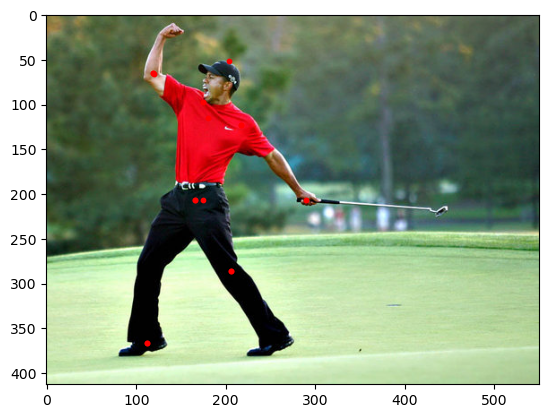

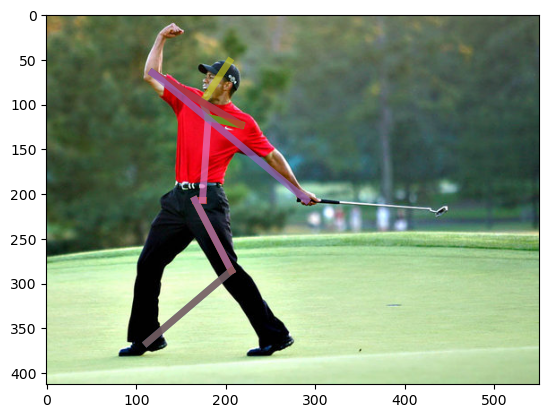

In [34]:
import os

test_image = os.path.join(PROJECT_PATH, 'data/test_image.jpg')

image, keypoints = predict(model, test_image)
draw_keypoints_on_image(image, keypoints)
draw_skeleton_on_image(image, keypoints)

In [35]:
# =========================
# SimpleBaseline + MPII JSON 파서 + 학습 루프
# =========================
import os, json, math, time, io, random, csv
from typing import List, Tuple, Optional
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# --------- 재현성 ----------
def seed_everything(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed); torch.backends.cudnn.deterministic = True
seed_everything(123)

# --------- 모델: SimpleBaseline ----------
class DeconvHead(nn.Module):
    def __init__(self, in_channels:int, num_keypoints:int, deconv_channels=(256,256,256)):
        super().__init__()
        layers = []
        prev = in_channels
        for c in deconv_channels:
            layers += [
                nn.ConvTranspose2d(prev, c, kernel_size=4, stride=2, padding=1, bias=False),
                nn.BatchNorm2d(c),
                nn.ReLU(inplace=True),
            ]
            prev = c
        self.deconvs = nn.Sequential(*layers)
        self.final = nn.Conv2d(prev, num_keypoints, kernel_size=1, stride=1, padding=0)

        for m in self.deconvs.modules():
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        nn.init.normal_(self.final.weight, std=0.001)
        if self.final.bias is not None:
            nn.init.constant_(self.final.bias, 0.0)

    def forward(self, x):
        x = self.deconvs(x)
        return self.final(x)

class BasicBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU(inplace=True)
    def forward(self, x): return self.relu(self.bn(self.conv(x)))

class TinyResNetStem(nn.Module):
    """입력을 1/32 해상도까지 줄이는 가벼운 stem"""
    def __init__(self, in_ch=3):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, 64, 7, stride=2, padding=3, bias=False)  # /2
        self.bn1   = nn.BatchNorm2d(64)
        self.relu  = nn.ReLU(inplace=True)
        self.pool  = nn.MaxPool2d(3, stride=2, padding=1)                      # /4
        self.layer1 = nn.Sequential(BasicBlock(64, 64, 1),  BasicBlock(64, 64, 1))   # /4
        self.layer2 = nn.Sequential(BasicBlock(64,128,2),  BasicBlock(128,128,1))    # /8
        self.layer3 = nn.Sequential(BasicBlock(128,256,2), BasicBlock(256,256,1))    # /16
        self.layer4 = nn.Sequential(BasicBlock(256,512,2), BasicBlock(512,512,1))    # /32

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)
        x = self.layer1(x); x = self.layer2(x); x = self.layer3(x); x = self.layer4(x)
        return x  # (B,512,H/32,W/32)

class SimpleBaseline(nn.Module):
    def __init__(self, num_keypoints:int):
        super().__init__()
        self.stem = TinyResNetStem(in_ch=3)
        self.head = DeconvHead(in_channels=512, num_keypoints=num_keypoints)

    def forward(self, x):
        feats = self.stem(x)       # (B,512,H/32,W/32)
        heat = self.head(feats)    # (B,K,H/4,W/4)
        return heat

# --------- Heatmap 생성 유틸 ----------
def _gaussian_2d(shape, sigma=2):
    m, n = [(ss - 1.) / 2. for ss in shape]
    y, x = np.ogrid[-m:m+1, -n:n+1]
    h = np.exp(-(x*x + y*y) / (2*sigma*sigma))
    h[h < np.finfo(h.dtype).eps * h.max()] = 0
    return h

def draw_gaussian(heatmap, center, sigma=2):
    tmp_size = int(3 * sigma)
    mu_x = int(center[0]+0.5); mu_y = int(center[1]+0.5)
    h, w = heatmap.shape[-2:]
    ul = [int(mu_x - tmp_size), int(mu_y - tmp_size)]
    br = [int(mu_x + tmp_size + 1), int(mu_y + tmp_size + 1)]
    if (ul[0] >= w or ul[1] >= h or br[0] < 0 or br[1] < 0):
        return heatmap
    size = 2 * tmp_size + 1
    g = _gaussian_2d((size, size), sigma=sigma)
    g_x = max(0, -ul[0]), min(br[0], w) - ul[0]
    g_y = max(0, -ul[1]), min(br[1], h) - ul[1]
    img_x = max(0, ul[0]), min(br[0], w)
    img_y = max(0, ul[1]), min(br[1], h)
    heatmap[..., img_y[0]:img_y[1], img_x[0]:img_x[1]] = np.maximum(
        heatmap[..., img_y[0]:img_y[1], img_x[0]:img_x[1]],
        g[g_y[0]:g_y[1], g_x[0]:g_x[1]]
    )
    return heatmap

def create_heatmaps(joints_xy, joints_vis, out_h, out_w, num_keypoints, sigma=2):
    hm = np.zeros((num_keypoints, out_h, out_w), dtype=np.float32)
    target_weight = np.ones((num_keypoints, 1), dtype=np.float32)
    for i in range(num_keypoints):
        if joints_vis[i] < 0.5:
            target_weight[i] = 0.0
            continue
        draw_gaussian(hm[i], (joints_xy[i,0], joints_xy[i,1]), sigma=sigma)
    return hm, target_weight

# --------- Dataset ----------
class MPIIJsonDataset(Dataset):
    def __init__(self, json_path:str, image_root:str, num_keypoints:int=16,
                 input_size:Tuple[int,int]=(256,256), heat_ratio:int=4, sigma:int=2):
        super().__init__()
        self.items = self._load_items(json_path)
        self.image_root = image_root
        self.K = num_keypoints
        self.in_w, self.in_h = input_size
        self.out_w, self.out_h = self.in_w // heat_ratio, self.in_h // heat_ratio
        self.sigma = sigma

    def _load_items(self, json_path):
        with open(json_path, "r") as f:
            data = json.load(f)
        if isinstance(data, dict):
            if 'annotations' in data: return data['annotations']
            if 'images' in data: return data['images']
            if 'data' in data: return data['data']
        if isinstance(data, list): return data
        raise ValueError(f"알 수 없는 JSON 구조: {json_path}")

    @staticmethod
    def _pick(d:dict, keys:List[str]):
        for k in keys:
            if k in d and d[k] is not None:
                return d[k]
        return None

    def _load_image(self, rel_or_abs):
        p = rel_or_abs
        if not os.path.isabs(p):
            p = os.path.join(self.image_root, p)
        img = Image.open(p).convert("RGB")
        return img

    def _parse_kps(self, item):
        kps = self._pick(item, ['joints', 'keypoints', 'joints_2d'])
        if kps is None:
            raise ValueError("키포인트가 없는 샘플입니다.")
        kps = np.array(kps, dtype=np.float32)
        if kps.ndim == 1:
            K = self.K
            if len(kps) % K == 0:
                kps = kps.reshape(K, -1)
            else:
                raise ValueError("키포인트 길이가 K로 나누어 떨어지지 않습니다.")
        return kps

    def __len__(self): return len(self.items)

    def __getitem__(self, idx):
        it = self.items[idx]
        img_rel = self._pick(it, ['image', 'img_path', 'img_paths', 'image_path'])
        if img_rel is None and isinstance(it.get('image', None), dict):
            img_rel = it['image'].get('file_name') or it['image'].get('path')
        if img_rel is None:
            raise ValueError("이미지 경로를 찾을 수 없습니다.")

        img = self._load_image(img_rel)
        W, H = img.size

        img_res = img.resize((self.in_w, self.in_h), Image.BILINEAR)
        img_np = np.asarray(img_res).astype(np.float32) / 255.0
        img_np = img_np.transpose(2,0,1)

        kps = self._parse_kps(it)
        if kps.shape[1] == 3:
            joints = kps[:, :2]
            vis = (kps[:, 2] > 0).astype(np.float32)
        else:
            joints = kps[:, :2]
            vis = np.ones((kps.shape[0],), dtype=np.float32)

        if joints.shape[0] != self.K:
            if joints.shape[0] > self.K:
                joints = joints[:self.K]; vis = vis[:self.K]
            else:
                pad = self.K - joints.shape[0]
                joints = np.vstack([joints, np.zeros((pad,2), dtype=np.float32)])
                vis = np.concatenate([vis, np.zeros((pad,), dtype=np.float32)])

        sx, sy = self.in_w / W, self.in_h / H
        joints_scaled = joints.copy()
        joints_scaled[:,0] *= sx; joints_scaled[:,1] *= sy

        j_hm = joints_scaled / 4.0
        heatmaps, target_weight = create_heatmaps(j_hm, vis, self.out_h, self.out_w, self.K, sigma=self.sigma)

        return (
            torch.from_numpy(img_np).float(),        # (3,256,256)
            torch.from_numpy(heatmaps).float(),      # (K,64,64)
            torch.from_numpy(target_weight).float(), # (K,1)
        )

# --------- Hourglass-style 손실 ----------
FG_BOOST = 82.0

def hourglass_weighted_mse(pred, target, target_weight=None, fg_boost: float = FG_BOOST):
    loss = (pred - target) ** 2
    if target_weight is not None:
        tw = target_weight
        while tw.dim() < loss.dim():
            tw = tw.unsqueeze(-1)  # (B,K,1,1)
        loss = loss * tw
    if fg_boost is not None and fg_boost != 1.0:
        weights = (target > 0).float() * (fg_boost - 1.0) + 1.0
        loss = loss * weights
    return loss.mean()

# --------- 루프 ----------
def train_one_epoch(model, loader, optimizer, device, scaler=None):
    model.train()
    run, n = 0.0, 0
    for imgs, targets, tw in loader:
        imgs = imgs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        tw = tw.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        if scaler is not None:
            with torch.autocast(device_type=device.type, dtype=torch.float16 if device.type=='cuda' else torch.bfloat16):
                out = model(imgs)
                loss = hourglass_weighted_mse(out, targets, tw, fg_boost=FG_BOOST)
            scaler.scale(loss).backward()
            scaler.step(optimizer); scaler.update()
        else:
            out = model(imgs)
            loss = hourglass_weighted_mse(out, targets, tw, fg_boost=FG_BOOST)
            loss.backward(); optimizer.step()

        run += loss.item() * imgs.size(0); n += imgs.size(0)
    return run / max(n,1)

@torch.no_grad()
def validate_one_epoch(model, loader, device):
    model.eval()
    run, n = 0.0, 0
    for imgs, targets, tw in loader:
        imgs = imgs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        tw = tw.to(device, non_blocking=True)
        out = model(imgs)
        loss = hourglass_weighted_mse(out, targets, tw, fg_boost=FG_BOOST)
        run += loss.item() * imgs.size(0); n += imgs.size(0)
    return run / max(n,1)

def _save_loss_history_csv(save_dir:str, tag:str, train_hist:list, val_hist:list) -> str:
    os.makedirs(save_dir, exist_ok=True)
    path = os.path.join(save_dir, f"{tag}_loss_history.csv")
    with open(path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["epoch", "train_loss", "val_loss"])
        for i, (tr, va) in enumerate(zip(train_hist, val_hist), start=1):
            w.writerow([i, tr, va])
    return path

# --------- train() 진입점 ----------
def train(epochs:int, learning_rate:float, num_heatmap:int, batch_size:int,
          TRAIN_JSON:str, VAL_JSON:str, IMAGE_DIR:str,
          save_dir:str=os.path.expanduser('~/work/mpii/models'),
          tag:str="simplebaseline",
          save_csv: bool = True) -> dict:
    os.makedirs(save_dir, exist_ok=True)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # datasets & loaders
    train_ds = MPIIJsonDataset(TRAIN_JSON, IMAGE_DIR, num_keypoints=num_heatmap)
    val_ds   = MPIIJsonDataset(VAL_JSON, IMAGE_DIR, num_keypoints=num_heatmap)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=2, pin_memory=True, drop_last=False)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                              num_workers=2, pin_memory=True, drop_last=False)

    # model/opt
    model = SimpleBaseline(num_keypoints=num_heatmap).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

    # loop — 히스토리 기록
    best_val, best_path = math.inf, ""
    train_hist, val_hist = [], []

    for epoch in range(1, epochs+1):
        tr = train_one_epoch(model, train_loader, optimizer, device, scaler)
        va = validate_one_epoch(model, val_loader, device)
        train_hist.append(float(tr)); val_hist.append(float(va))
        print(f"[Epoch {epoch}/{epochs}] train_loss={tr:.4f}  val_loss={va:.4f}")

        # save checkpoint
        ck = os.path.join(save_dir, f"{tag}-epoch-{epoch}-valloss-{va:.4f}.pt")
        torch.save({"model": model.state_dict(), "epoch": epoch, "val_loss": va}, ck)

        if va < best_val:
            best_val, best_path = va, os.path.join(save_dir, f"{tag}-best.pt")
            torch.save({"model": model.state_dict(), "epoch": epoch, "val_loss": va}, best_path)
            print(f"Model improved. Saved best → {best_path}")

    csv_path = None
    if save_csv:
        csv_path = _save_loss_history_csv(save_dir, tag, train_hist, val_hist)
        print(f"Saved loss CSV → {csv_path}")

    return {
        "best_model_path": best_path or ck,
        "best_val": best_val,
        "train_loss_history": train_hist,
        "val_loss_history": val_hist,
        "loss_csv": csv_path,
    }


In [38]:
epochs = 10
best_model_file = train(epochs, learning_rate, num_heatmap, batch_size, TRAIN_JSON, VAL_JSON, IMAGE_DIR)
print("Best model saved at:", best_model_file)

/tmp/ipykernel_1233/2999466665.py:307: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


[Epoch 1/10] train_loss=0.0027  val_loss=0.0026
Model improved. Saved best → /home/jovyan/work/mpii/models/simplebaseline-best.pt
[Epoch 2/10] train_loss=0.0025  val_loss=0.0025
Model improved. Saved best → /home/jovyan/work/mpii/models/simplebaseline-best.pt
[Epoch 3/10] train_loss=0.0024  val_loss=0.0024
Model improved. Saved best → /home/jovyan/work/mpii/models/simplebaseline-best.pt
[Epoch 4/10] train_loss=0.0023  val_loss=0.0024
Model improved. Saved best → /home/jovyan/work/mpii/models/simplebaseline-best.pt
[Epoch 5/10] train_loss=0.0023  val_loss=0.0023
Model improved. Saved best → /home/jovyan/work/mpii/models/simplebaseline-best.pt
[Epoch 6/10] train_loss=0.0022  val_loss=0.0023
Model improved. Saved best → /home/jovyan/work/mpii/models/simplebaseline-best.pt
[Epoch 7/10] train_loss=0.0022  val_loss=0.0023
Model improved. Saved best → /home/jovyan/work/mpii/models/simplebaseline-best.pt
[Epoch 8/10] train_loss=0.0021  val_loss=0.0023
Model improved. Saved best → /home/jovyan/

In [36]:
# 모델 비교
import os
import torch

# --- 공통 설정 ---
WEIGHTS_PATH_HOURGLASS = os.path.join(PROJECT_PATH, 'models', 'model-epoch-2-loss-1.2050.pt')
WEIGHTS_PATH_BASELINE  = os.path.join(PROJECT_PATH, 'models', 'simplebaseline-best.pt')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1. StackedHourglass 모델 ---
model_hourglass = StackedHourglassNetwork(
    IMAGE_SHAPE, num_stack=4, num_residual=1, num_heatmap=num_heatmap
).to(device)

checkpoint_hg = torch.load(WEIGHTS_PATH_HOURGLASS, map_location=device)
model_hourglass.load_state_dict(checkpoint_hg)
model_hourglass.eval()

# --- 2. SimpleBaseline 모델 ---
model_baseline = SimpleBaseline(num_keypoints=num_heatmap).to(device)

if os.path.exists(WEIGHTS_PATH_BASELINE):
    checkpoint_sb = torch.load(WEIGHTS_PATH_BASELINE, map_location=device)
    if isinstance(checkpoint_sb, dict) and "model" in checkpoint_sb:
        model_baseline.load_state_dict(checkpoint_sb["model"])
    else:
        model_baseline.load_state_dict(checkpoint_sb)
    print("Loaded SimpleBaseline weights from", WEIGHTS_PATH_BASELINE)
else:
    print("No pretrained weights found for SimpleBaseline. Using random init.")

model_baseline.eval()


Loaded SimpleBaseline weights from /home/jovyan/work/mpii/models/simplebaseline-best.pt


SimpleBaseline(
  (stem): TinyResNetStem(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
      )
      (1): BasicBlock(
        (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
      )
    )
    (layer2): Sequential(
      (0): BasicBlock(
        (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), pad

In [37]:
!pip install -q ultralytics huggingface_hub opencv-python

In [38]:
import os, torch
from ultralytics import YOLO

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- (1) Hourglass ---
WEIGHTS_HOURGLASS = os.path.join(PROJECT_PATH, "models", "model-epoch-2-loss-1.2050.pt")
model_hourglass = StackedHourglassNetwork(
    IMAGE_SHAPE, num_stack=4, num_residual=1, num_heatmap=num_heatmap
).to(device)
ckpt_hourglass = torch.load(WEIGHTS_HOURGLASS, map_location=device)
model_hourglass.load_state_dict(ckpt_hourglass)
model_hourglass.eval()


# --- (2) SimpleBaseline ---
# (노트북 정의: SimpleBaseline(num_keypoints:int))
WEIGHTS_BASELINE = os.path.join(PROJECT_PATH, "models", "simplebaseline-best.pt")

model_baseline = SimpleBaseline(num_keypoints=num_heatmap).to(device)

ckpt_baseline = torch.load(WEIGHTS_BASELINE, map_location=device)
state_dict = ckpt_baseline.get("model", ckpt_baseline) if isinstance(ckpt_baseline, dict) else ckpt_baseline
model_baseline.load_state_dict(state_dict, strict=False)
model_baseline.eval()


# --- (3) YOLOv8 Pose (COCO 17 keypoints) ---
# HF 우회: ultralytics가 자체적으로 가중치 다운로드
model_yolo = YOLO("yolov8n-pose.pt").to(device)
model_yolo.eval()


# --- dict로 모으기 ---
models = {
    "Hourglass": model_hourglass,
    "SimpleBaseline": model_baseline,
    "YOLOv8n-pose": model_yolo
}

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/home/jovyan/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


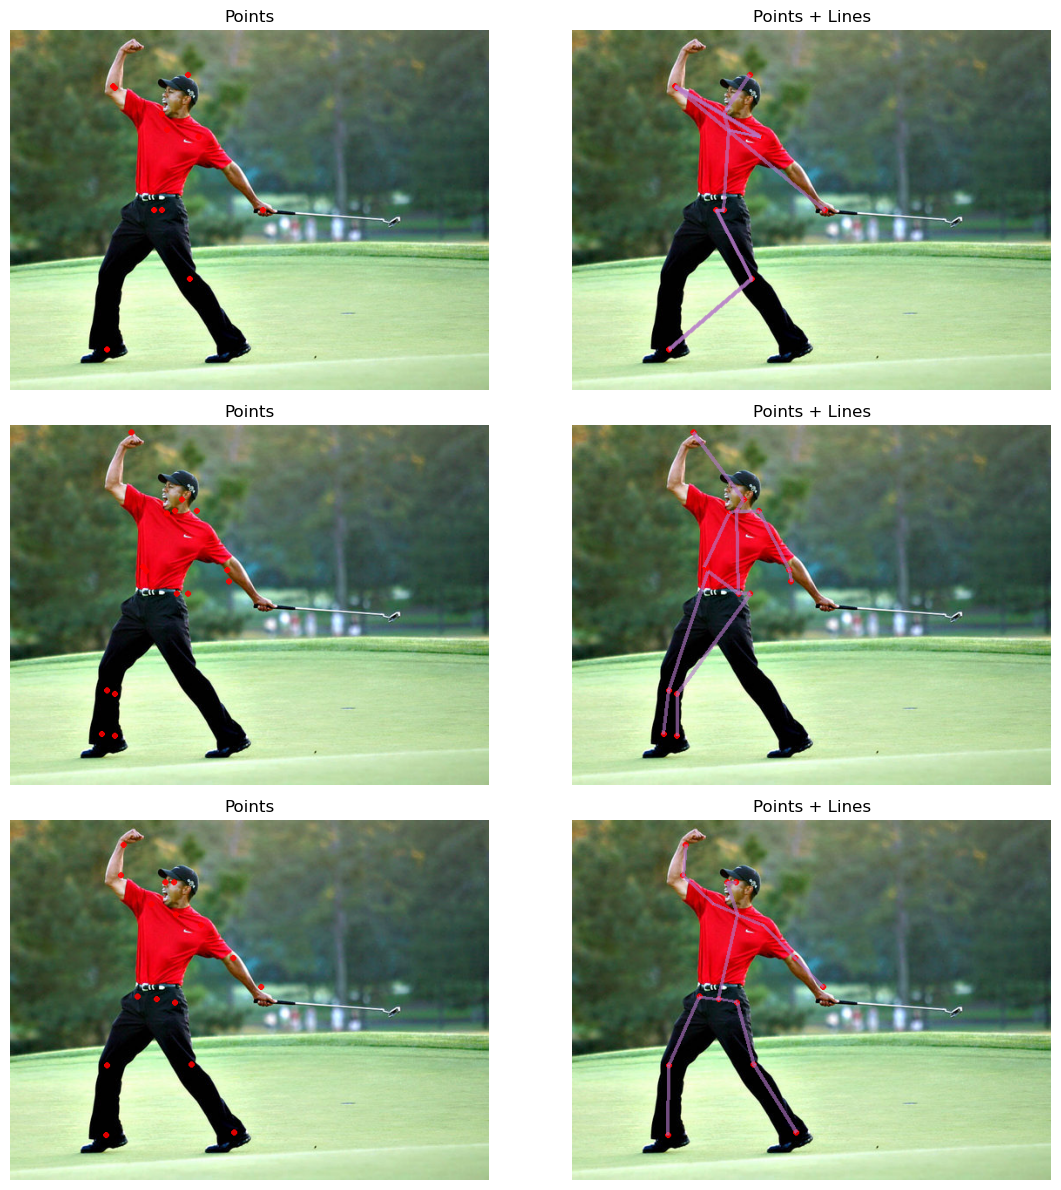

In [39]:
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

# ---------- YOLO(COCO 17) → MPII(16) 변환 (이전과 동일) ----------
def _mean_pts(arr, idxs):
    pts = np.stack([arr[i] for i in idxs], 0).astype(np.float32)
    return pts.mean(0)

def coco17_to_mpii16(kps17_norm):
    c = kps17_norm
    out = np.zeros((16, 2), dtype=np.float32)
    out[0]  = c[16]; out[1]  = c[14]; out[2]  = c[12]
    out[3]  = c[11]; out[4]  = c[13]; out[5]  = c[15]
    out[6]  = _mean_pts(c, [11,12])         # pelvis
    out[7]  = _mean_pts(c, [5,6])           # thorax
    out[8]  = c[0]                          # upper neck ~= nose
    out[9]  = _mean_pts(c, [1,2,3,4])       # head top ~= mean(eyes/ears)
    out[10] = c[10]; out[11] = c[8]; out[12] = c[6]
    out[13] = c[5];  out[14] = c[7]; out[15] = c[9]
    return out

def yolo_pose_predict_norm_mpii(model, image_path):
    results = model(image_path, verbose=False)
    r = results[0]
    img = Image.open(image_path).convert("RGB")
    W, H = img.size
    if r.keypoints is None or len(r.keypoints) == 0:
        kps17 = np.tile(np.array([[0.5, 0.5]], np.float32), (17, 1))
    else:
        if r.boxes is not None and len(r.boxes) > 0:
            areas = (r.boxes.xyxy[:,2] - r.boxes.xyxy[:,0]) * (r.boxes.xyxy[:,3] - r.boxes.xyxy[:,1])
            idx = int(areas.argmax().item())
        else:
            idx = 0
        kps_px = r.keypoints.xy[idx].cpu().numpy().astype(np.float32)
        kps17 = kps_px.copy(); kps17[:,0] /= W; kps17[:,1] /= H
    kps_mpii = coco17_to_mpii16(kps17)
    return img, kps_mpii

# ---------- MPII 스켈레톤(16점) ----------
MPII_BONES = [
    (0,1),(1,2),(2,6),(3,6),(3,4),(4,5),
    (6,7),(7,8),(8,9),
    (10,11),(11,12),(7,12),(7,13),(13,14),(14,15)
]

# ---------- PIL에 직접 그리는 버전 (새 Figure를 만들지 않음) ----------
def draw_points_pil(img, kps_norm, r=3, color=(255,0,0)):
    """img: PIL.Image, kps_norm: (K,2) in [0,1]"""
    W, H = img.size
    draw = ImageDraw.Draw(img, 'RGBA')
    for (x, y) in kps_norm:
        cx, cy = x*W, y*H
        draw.ellipse([(cx-r, cy-r), (cx+r, cy+r)], fill=color+(220,), outline=color+(255,))
    return img

def draw_lines_pil(img, kps_norm, bones=MPII_BONES, width=4, color=(180,120,200)):
    W, H = img.size
    draw = ImageDraw.Draw(img, 'RGBA')
    for a, b in bones:
        x1, y1 = kps_norm[a][0]*W, kps_norm[a][1]*H
        x2, y2 = kps_norm[b][0]*W, kps_norm[b][1]*H
        draw.line([(x1,y1),(x2,y2)], fill=color+(160,), width=width)
    return img

# ---------- 공통 predict: 모두 MPII(16) 정규화 좌표로 통일 ----------
def predict_for_any_mpii(name, mdl, image_path):
    if name.lower().startswith("yolo"):
        return yolo_pose_predict_norm_mpii(mdl, image_path)
    else:
        # 기존 predict는 MPII(16) 정규화 좌표 반환 가정
        return predict(mdl, image_path)

# ---------- 원하는 레이아웃: 각 행에 (Points, Points+Lines)만 ----------
def compare_models_two_per_row(models_dict, image_path):
    rows, cols = len(models_dict), 2
    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))
    # axes를 2차원 보장
    if rows == 1:
        axes = np.array([axes])

    for r, (name, mdl) in enumerate(models_dict.items()):
        img, kps = predict_for_any_mpii(name, mdl, image_path)

        # (1) 점만
        img_pts = img.copy()
        draw_points_pil(img_pts, kps)

        # (2) 점 + 선
        img_both = img.copy()
        draw_points_pil(img_both, kps)
        draw_lines_pil(img_both, kps)

        ax1, ax2 = axes[r, 0], axes[r, 1]
        ax1.imshow(img_pts);  ax1.set_title("Points");         ax1.axis('off')
        ax2.imshow(img_both); ax2.set_title("Points + Lines"); ax2.axis('off')
        # 좌측에 모델 이름만 한 번
        ax1.set_ylabel(name, rotation=0, ha="right", va="center",
                       fontsize=12, fontweight="bold", labelpad=20)

    plt.tight_layout()
    plt.show()

# ---------- 실행 ----------
test_image = os.path.join(PROJECT_PATH, "data/test_image.jpg")
compare_models_two_per_row(models, test_image)


In [41]:
import matplotlib.pyplot as plt
from PIL import ImageDraw

def evaluate_pckh_with_logs(models_dict, json_path, image_dir, tau=0.5, max_items=None):
    """
    각 모델에 대해 PCKh + per-image log를 반환.
    logs[model] = [ {img_path, gt, pred_px, vis, head_size, ok(16,), dists(16,)} ... ]
    """
    items = _load_mpii_val_items(json_path, image_dir)
    if max_items is not None:
        items = items[:max_items]

    results, logs = {}, {}

    for name, mdl in models_dict.items():
        correct = np.zeros(16, dtype=np.int64)
        total   = np.zeros(16, dtype=np.int64)
        logs[name] = []

        for ann in items:
            img_path = ann["img_path"]
            gt  = ann["joints"]     # (16,2)
            vis = ann["vis"]
            hs  = ann["head_size"]

            # 예측
            img = Image.open(img_path).convert("RGB")
            W, H = img.size
            _, pred_norm = predict_for_any_mpii(name, mdl, img_path)

            if isinstance(pred_norm, torch.Tensor):
                pred_norm = pred_norm.detach().cpu().numpy()
            else:
                pred_norm = np.array(pred_norm, dtype=np.float32)

            pred_px = pred_norm.copy()
            pred_px[:,0] *= W
            pred_px[:,1] *= H

            head_size = hs if (hs is not None and hs > 0) else 0.25 * min(W,H)
            thr = tau * head_size

            dists = np.linalg.norm(pred_px - gt, axis=1)  # (16,)
            ok    = (dists <= thr) & (vis > 0)

            correct += ok.astype(np.int64)
            total   += (vis > 0).astype(np.int64)

            logs[name].append({
                "img_path": img_path,
                "gt": gt, "pred": pred_px, "vis": vis,
                "head_size": head_size,
                "dists": dists, "ok": ok
            })

        pckh_joint = np.where(total > 0, correct / total, 0.0)
        pckh_mean  = float(pckh_joint.mean())
        results[name] = {
            "pckh_per_joint": pckh_joint,
            "pckh_mean": pckh_mean,
            "counts": total
        }

    return results, logs


# --- 시각화 함수 ---
def visualize_failure_case(log_entry, title=""):
    """
    GT skeleton (녹색), Pred skeleton (빨강) 함께 시각화
    """
    img = Image.open(log_entry["img_path"]).convert("RGB")
    draw = ImageDraw.Draw(img, "RGBA")

    gt = log_entry["gt"]
    pred = log_entry["pred"]
    vis = log_entry["vis"]

    # GT skeleton (녹색)
    for a,b in MPII_BONES:
        if vis[a] and vis[b]:
            draw.line([(gt[a,0], gt[a,1]), (gt[b,0], gt[b,1])], fill=(0,255,0,180), width=3)
    for (x,y),v in zip(gt,vis):
        if v: draw.ellipse([(x-2,y-2),(x+2,y+2)], fill=(0,255,0,255))

    # Pred skeleton (빨강)
    for a,b in MPII_BONES:
        draw.line([(pred[a,0], pred[a,1]), (pred[b,0], pred[b,1])], fill=(255,0,0,180), width=3)
    for (x,y) in pred:
        draw.ellipse([(x-2,y-2),(x+2,y+2)], fill=(255,0,0,255))

    plt.imshow(img); plt.title(title); plt.axis("off")


def show_worst_cases(logs, model_name, top_k=5):
    """
    PCKh가 낮은 상위 K 이미지를 시각화
    """
    entries = logs[model_name]
    # 이미지별 평균 OK 비율
    scored = [(e["ok"].mean(), e) for e in entries]
    scored.sort(key=lambda x: x[0])  # 낮은 점수 순

    worst = scored[:top_k]
    plt.figure(figsize=(5*top_k,5))
    for i, (score,e) in enumerate(worst,1):
        plt.subplot(1, top_k, i)
        visualize_failure_case(e, title=f"{os.path.basename(e['img_path'])}\nAcc={score:.2f}")
    plt.show()


=== Hourglass | Mean PCKh@0.50: 0.1942 ===
         R_Ank: 0.0462  (n=65)
        R_Knee: 0.0723  (n=83)
         R_Hip: 0.0412  (n=97)
         L_Hip: 0.1042  (n=96)
        L_Knee: 0.0723  (n=83)
         L_Ank: 0.0455  (n=66)
        Pelvis: 0.0625  (n=96)
        Thorax: 0.4184  (n=98)
     UpperNeck: 0.3980  (n=98)
       HeadTop: 0.3776  (n=98)
       R_Wrist: 0.1546  (n=97)
       R_Elbow: 0.2424  (n=99)
    R_Shoulder: 0.3265  (n=98)
    L_Shoulder: 0.3232  (n=99)
       L_Elbow: 0.2800  (n=100)
       L_Wrist: 0.1429  (n=98)

=== SimpleBaseline | Mean PCKh@0.50: 0.2110 ===
         R_Ank: 0.0308  (n=65)
        R_Knee: 0.1205  (n=83)
         R_Hip: 0.2680  (n=97)
         L_Hip: 0.2812  (n=96)
        L_Knee: 0.1205  (n=83)
         L_Ank: 0.0152  (n=66)
        Pelvis: 0.3125  (n=96)
        Thorax: 0.2755  (n=98)
     UpperNeck: 0.2959  (n=98)
       HeadTop: 0.3571  (n=98)
       R_Wrist: 0.1753  (n=97)
       R_Elbow: 0.1919  (n=99)
    R_Shoulder: 0.2449  (n=98)
    L_Sh

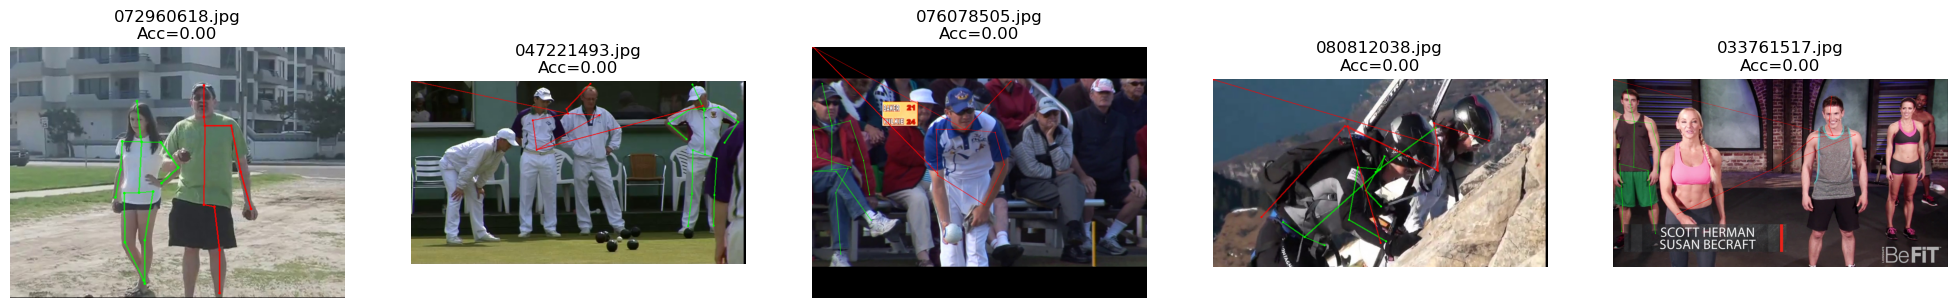

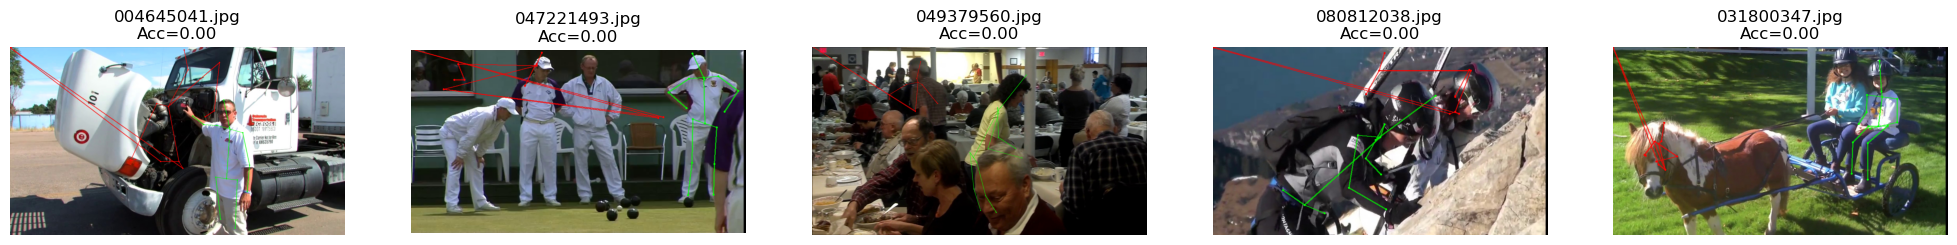

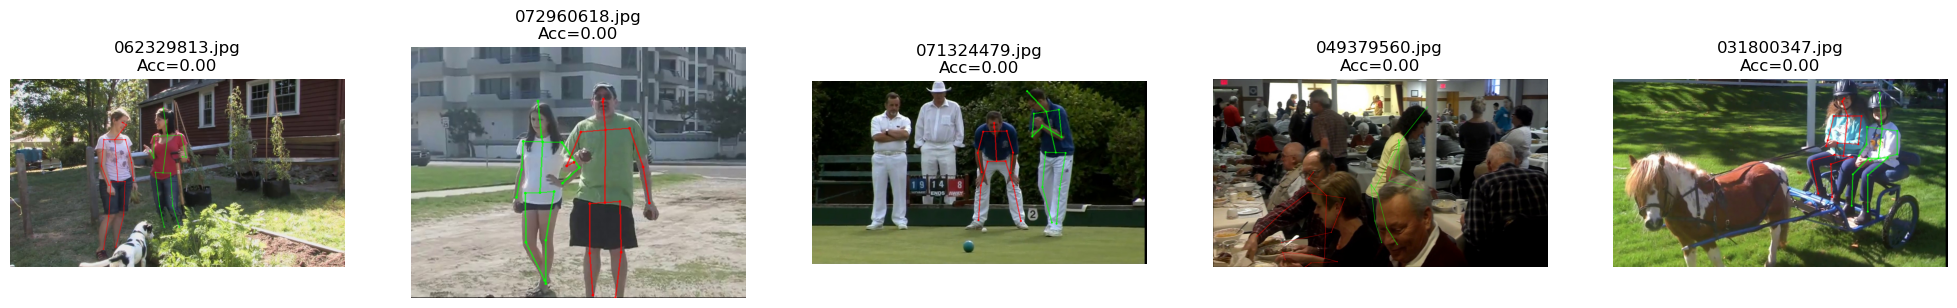

In [42]:
# 1. 평가 및 로그 수집
results, logs = evaluate_pckh_with_logs(models, VAL_JSON, IMAGE_DIR, tau=0.5, max_items=100)

print_pckh_table(results, tau=0.5)

# 2. 성능 낮은 이미지 시각화
show_worst_cases(logs, "Hourglass", top_k=5)
show_worst_cases(logs, "SimpleBaseline", top_k=5)
show_worst_cases(logs, "YOLOv8n-pose", top_k=5)

## 문제와 해결 방안
여러 사람이 한 이미지에 있을 경우 GT와 prediction 이 서로 다른 사람에 대해 그려지는 경우가 있고 이때 Acc 는 0이 됨.

해결 방안:
YOLO : multi-person 에 대한 학습이 이뤄진 모델이므로 GT 와 가장 가까운 사람에 대한 pred 로 평가
Hourglass/Simplebaseline : detection 모델로 bbox 를 그리고 각각에 대해 crop 한 뒤 pred 수행 -> 좌표를 원본으로 되돌리고 GT 와 가장 가까운 사람에 대한 pred 로 평가

In [52]:
import os, json, math, tempfile
import numpy as np, torch
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

# --------- MPII meta ---------
MPII_BONES = [
    (0,1),(1,2),(2,6),(3,6),(3,4),(4,5),
    (6,7),(7,8),(8,9),
    (10,11),(11,12),(7,12),(7,13),(13,14),(14,15)
]
MPII_NAMES = [
    "R_Ank","R_Knee","R_Hip","L_Hip","L_Knee","L_Ank",
    "Pelvis","Thorax","UpperNeck","HeadTop",
    "R_Wrist","R_Elbow","R_Shoulder","L_Shoulder","L_Elbow","L_Wrist"
]

# --------- utils: IoU, GT bbox, loader ---------
def iou_xyxy(a, b):
    ax1,ay1,ax2,ay2 = a; bx1,by1,bx2,by2 = b
    ix1,iy1 = max(ax1,bx1), max(ay1,by1)
    ix2,iy2 = min(ax2,bx2), min(ay2,by2)
    iw, ih = max(0, ix2-ix1), max(0, iy2-iy1)
    inter = iw*ih
    area_a = max(0, ax2-ax1)*max(0, ay2-ay1)
    area_b = max(0, bx2-bx1)*max(0, by2-by1)
    union = area_a + area_b - inter + 1e-6
    return inter / union

def _find_head_box(ann):
    for k in ["head_box","head_bbox","headRect","head_bndbox","head","bbox_head"]:
        if k in ann:
            box = ann[k]
            if isinstance(box, (list,tuple)) and len(box)==4: return list(map(float, box))
            if isinstance(box, dict) and all(z in box for z in ("x1","y1","x2","y2")):
                return [float(box["x1"]), float(box["y1"]), float(box["x2"]), float(box["y2"])]
    if "headboxes" in ann and isinstance(ann["headboxes"], (list,tuple)) and len(ann["headboxes"])==2:
        (x1,y1),(x2,y2) = ann["headboxes"]; return [float(x1),float(y1),float(x2),float(y2)]
    return None

def _head_size_from_box(box):
    x1,y1,x2,y2 = box
    return float(math.hypot(x2-x1, y2-y1))

def _load_mpii_val_items(json_path, image_dir):
    with open(json_path, "r") as f: data = json.load(f)
    items = []
    for ann in data:
        if   "img_paths" in ann: img_rel = ann["img_paths"]
        elif "image"     in ann: img_rel = ann["image"]
        elif "img_path"  in ann: img_rel = ann["img_path"]
        else: continue
        img_path = os.path.join(image_dir, img_rel)

        joints = None
        for k in ["joints","joints_xy","keypoints","kpts"]:
            if k in ann: joints = np.array(ann[k], dtype=np.float32); break
        if joints is None: continue
        if joints.shape[-1] != 2: joints = joints[...,:2]
        if joints.shape[0] != 16: continue

        vis = None
        for k in ["joints_vis","vis","visible"]:
            if k in ann: v = np.array(ann[k]).reshape(-1); vis = (v>0).astype(np.uint8); break
        if vis is None: vis = np.ones((16,), dtype=np.uint8)

        head_box  = _find_head_box(ann)
        head_size = _head_size_from_box(head_box) if head_box is not None else None

        items.append({"img_path": img_path, "joints": joints, "vis": vis,
                      "head_size": head_size, "ann_raw": ann})
    return items

def _gt_center_and_scale(ann):
    cx = cy = None
    if "objpos" in ann and isinstance(ann["objpos"], dict):
        cx = float(ann["objpos"].get("x", None))
        cy = float(ann["objpos"].get("y", None))
    s = float(ann.get("scale", 0.0)) if "scale" in ann else 0.0
    return cx, cy, s

def bbox_from_objpos_scale(ann, W, H, margin=1.25):
    cx, cy, s = _gt_center_and_scale(ann)
    if cx is None or cy is None or s is None or s <= 0: return None
    side = 200.0 * s * margin
    x1 = max(0.0, cx - side/2); y1 = max(0.0, cy - side/2)
    x2 = min(float(W), cx + side/2); y2 = min(float(H), cy + side/2)
    if x2 <= x1 or y2 <= y1: return None
    return [x1,y1,x2,y2]

def bbox_from_gt_joints(ann, W, H, pad_ratio=0.25):
    pts = None
    for k in ["joints","joints_xy","keypoints","kpts"]:
        if k in ann: pts = np.array(ann[k], dtype=np.float32); break
    if pts is None or pts.size == 0: return None
    if pts.shape[-1] == 3: pts = pts[...,:2]
    x1,y1 = pts[:,0].min(), pts[:,1].min()
    x2,y2 = pts[:,0].max(), pts[:,1].max()
    w,h = x2-x1, y2-y1
    if w<=1 or h<=1: return None
    x1 -= w*pad_ratio; y1 -= h*pad_ratio
    x2 += w*pad_ratio; y2 += h*pad_ratio
    x1 = max(0.0,x1); y1 = max(0.0,y1); x2 = min(float(W),x2); y2 = min(float(H),y2)
    if x2 <= x1 or y2 <= y1: return None
    return [x1,y1,x2,y2]

# --------- detector: 사람 박스 ---------
def detect_person_bboxes_yolo(detector, image_path, conf=0.25):
    res = detector(image_path, verbose=False, conf=conf)[0]
    if res.boxes is None or len(res.boxes) == 0: return []
    b = res.boxes
    if hasattr(b, "cls") and b.cls is not None:
        keep = (b.cls.cpu().numpy().astype(int) == 0)  # COCO: 0=person
        xyxy = b.xyxy.cpu().numpy()[keep]
    else:
        xyxy = b.xyxy.cpu().numpy()
    return [list(map(float, bb)) for bb in xyxy]

def select_bbox_by_iou(detector, img_path, ann, iou_thr=0.2):
    """GT bbox와 IoU가 가장 큰 detector bbox 선택. 임계값 미만이면 GT bbox 사용."""
    with Image.open(img_path) as im: W,H = im.size
    gt_bb = bbox_from_objpos_scale(ann, W, H, margin=1.25) or \
            bbox_from_gt_joints(ann, W, H, pad_ratio=0.25)
    if gt_bb is None:  # 아주 드문 경우
        return None, None

    det_bbs = detect_person_bboxes_yolo(detector, img_path)
    if not det_bbs:
        return gt_bb, None

    best, best_iou = None, -1.0
    for bb in det_bbs:
        iou = iou_xyxy(gt_bb, bb)
        if iou > best_iou:
            best, best_iou = bb, iou

    # IoU가 작으면 detector 신뢰X → GT bbox 사용
    if best_iou < iou_thr:
        return gt_bb, best  # (selected=gt, vis_det=best for display)
    else:
        return best, gt_bb   # (selected=det, vis_gt=gt for display)

# --------- crop → 기존 predict 재사용 → 원본 정규화 좌표 복원 ---------
def predict_on_bbox_single_person(mdl, image_path, bbox_xyxy):
    img = Image.open(image_path).convert("RGB")
    W, H = img.size
    x1,y1,x2,y2 = bbox_xyxy
    crop = img.crop((x1,y1,x2,y2))
    cw,ch = crop.size
    with tempfile.NamedTemporaryFile(suffix=".jpg", delete=False) as f:
        tmp_path = f.name
    crop.save(tmp_path)
    try:
        _, kps_norm_crop = predict(mdl, tmp_path)  # (K,2) in [0,1] (crop 기준)
    finally:
        try: os.remove(tmp_path)
        except: pass
    kps_norm_crop = np.array(kps_norm_crop, dtype=np.float32)
    kps_norm_orig = kps_norm_crop.copy()
    kps_norm_orig[:,0] = (kps_norm_crop[:,0]*cw + x1) / W
    kps_norm_orig[:,1] = (kps_norm_crop[:,1]*ch + y1) / H
    return kps_norm_orig

# --------- 평가 (IoU 매칭 사용) ---------
def evaluate_pckh_sp_iou(models_sp, detector, json_path, image_dir, tau=0.5, iou_thr=0.2,
                         max_items=None, verbose_every=200):
    """
    GT bbox와 detector bbox를 IoU로 매칭해서 SP 모델 평가.
    반환:
      results, logs  (logs는 시각화에 사용)
    """
    items = _load_mpii_val_items(json_path, image_dir)
    if max_items is not None: items = items[:max_items]

    results = {}
    logs = {name: [] for name in models_sp}

    for name, mdl in models_sp.items():
        correct = np.zeros(16, dtype=np.int64)
        total   = np.zeros(16, dtype=np.int64)

        for i, it in enumerate(items, 1):
            img_path, gt, vis, hs, ann = it["img_path"], it["joints"], it["vis"], it["head_size"], it["ann_raw"]
            with Image.open(img_path) as im: W,H = im.size

            sel_bb, other_bb = select_bbox_by_iou(detector, img_path, ann, iou_thr=iou_thr)
            if sel_bb is None:
                continue

            pred_norm = predict_on_bbox_single_person(mdl, img_path, sel_bb)
            pred_px = pred_norm.copy()
            pred_px[:,0] *= W; pred_px[:,1] *= H

            head_size = hs if (hs is not None and hs > 0) else 0.25*min(W, H)
            thr = tau * head_size
            dists = np.linalg.norm(pred_px - gt, axis=1)
            ok = (dists <= thr) & (vis > 0)
            pckh_img = float(np.nanmean(np.where(vis>0, ok.astype(np.float32), np.nan)))

            correct += ok.astype(np.int64)
            total   += (vis > 0).astype(np.int64)

            # 로그 (GT bbox는 other_bb일 수 있음 → 표시용으로 둘 다 저장)
            # selected_bbox: 실제 crop에 사용한 박스
            # gt_bbox_vis  : 기준 GT 박스(시각화용)
            # det_bbox_vis : detector에서 최고 IoU 박스(시각화용)
            # select_bbox_by_iou의 반환 규칙상, 두 값 중 하나가 GT, 하나가 DET
            gt_bb = bbox_from_objpos_scale(ann, W, H, margin=1.25) or \
                    bbox_from_gt_joints(ann, W, H, pad_ratio=0.25)
            det_bbs = detect_person_bboxes_yolo(detector, img_path)
            # best det bbox (표시용)
            best_det = None; best_i = -1
            for bb in det_bbs:
                v = iou_xyxy(gt_bb, bb)
                if v > best_i: best_det, best_i = bb, v

            logs[name].append({
                "img_path": img_path, "gt_px": gt, "pred_px": pred_px, "vis": vis,
                "selected_bbox": sel_bb, "gt_bbox": gt_bb, "det_bbox": best_det,
                "pckh_img": pckh_img, "best_iou": float(best_i)
            })

            if verbose_every and (i % verbose_every == 0):
                print(f"[{name}] {i}/{len(items)}")

        pckh_joint = np.where(total>0, correct/total, 0.0)
        results[name] = {"pckh_per_joint": pckh_joint, "pckh_mean": float(pckh_joint.mean()), "counts": total}
    return results, logs

# --------- 시각화(개선: GT/Detector/선택 박스 모두 표시) ---------
def draw_gt_pred_and_bboxes(img_path, gt_px, pred_px, vis, gt_bbox=None, det_bbox=None,
                            selected_bbox=None, title=""):
    img = Image.open(img_path).convert("RGB")
    d = ImageDraw.Draw(img, "RGBA")
    if gt_bbox is not None:
        x1,y1,x2,y2 = gt_bbox; d.rectangle([x1,y1,x2,y2], outline=(0,255,255,220), width=3) # cyan: GT
    if det_bbox is not None:
        x1,y1,x2,y2 = det_bbox; d.rectangle([x1,y1,x2,y2], outline=(255,165,0,220), width=3) # orange: best DET
    if selected_bbox is not None:
        x1,y1,x2,y2 = selected_bbox; d.rectangle([x1,y1,x2,y2], outline=(255,0,255,220), width=3) # magenta: used
    # GT (green)
    for a,b in MPII_BONES:
        if vis[a] and vis[b]:
            d.line([(gt_px[a,0],gt_px[a,1]), (gt_px[b,0],gt_px[b,1])], fill=(0,255,0,180), width=3)
    for (x,y),v in zip(gt_px, vis):
        if v: d.ellipse([(x-3,y-3),(x+3,y+3)], fill=(0,255,0,255))
    # Pred (red)
    for a,b in MPII_BONES:
        d.line([(pred_px[a,0],pred_px[a,1]), (pred_px[b,0],pred_px[b,1])], fill=(255,0,0,180), width=3)
    for (x,y) in pred_px:
        d.ellipse([(x-3,y-3),(x+3,y+3)], fill=(255,0,0,255))
    plt.imshow(img); plt.title(title); plt.axis("off")

def show_worst_sp_with_bboxes(logs, model_name, top_k=5):
    entries = sorted(logs[model_name], key=lambda e: e["pckh_img"])[:top_k]
    if not entries:
        print(f"[{model_name}] no samples.")
        return
    plt.figure(figsize=(5*len(entries), 5))
    for i, e in enumerate(entries, 1):
        plt.subplot(1, len(entries), i)
        title = f"{os.path.basename(e['img_path'])}\nAcc={e['pckh_img']:.2f} | IoU={e['best_iou']:.2f}"
        draw_gt_pred_and_bboxes(
            e["img_path"], e["gt_px"], e["pred_px"], e["vis"],
            gt_bbox=e["gt_bbox"], det_bbox=e["det_bbox"], selected_bbox=e["selected_bbox"], title=title
        )
    plt.suptitle(f"Worst {top_k} — {model_name} (GT cyan / DET orange / Used magenta)", fontsize=14)
    plt.tight_layout(); plt.show()


In [54]:
# ============================
# YOLO Pose (COCO17) → MPII16  매핑
# ============================
import numpy as np, os
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

# COCO keypoint index 참고:
# 0:nose 1:leye 2:reye 3:lear 4:rear 5:ls 6:rs 7:le 8:re 9:lw 10:rw
# 11:lh 12:rh 13:lk 14:rk 15:la 16:ra

def coco17_to_mpii16(kps_coco_norm):
    """
    kps_coco_norm: (17,2) in [0,1]
    return: (16,2) MPII order (대략적 근사)
    """
    c = kps_coco_norm
    pelvis = (c[11] + c[12]) / 2.0
    thorax = (c[5]  + c[6])  / 2.0
    # UpperNeck/HeadTop 근사: nose 사용(더 정교하게 하려면 eyes/ears 평균을 쓰세요)
    upperneck = c[0].copy()
    headtop   = c[0].copy()

    mpii = np.stack([
        c[16],   # 0 R_Ank
        c[14],   # 1 R_Knee
        c[12],   # 2 R_Hip
        c[11],   # 3 L_Hip
        c[13],   # 4 L_Knee
        c[15],   # 5 L_Ank
        pelvis,  # 6 Pelvis
        thorax,  # 7 Thorax
        upperneck, # 8 UpperNeck
        headtop,   # 9 HeadTop
        c[10],   # 10 R_Wrist
        c[8],    # 11 R_Elbow
        c[6],    # 12 R_Shoulder
        c[5],    # 13 L_Shoulder
        c[7],    # 14 L_Elbow
        c[9],    # 15 L_Wrist
    ], axis=0).astype(np.float32)
    return mpii

# ============================
# YOLO 포즈 → 모든 사람의 (bbox, MPII16 정규화) 추출
# ============================
def yolo_pose_predict_all_mpii(yolo_pose_model, image_path):
    """
    반환: list of dict
      {
        "bbox_xyxy": [x1,y1,x2,y2] (pixel),
        "kps_mpii_norm": (16,2) in [0,1]
      }
    """
    res = yolo_pose_model(image_path, verbose=False)[0]
    img = Image.open(image_path).convert("RGB")
    W, H = img.size

    out = []
    if res.keypoints is None or len(res.keypoints) == 0:
        return out

    kps_all = res.keypoints.xy  # (N,17,2) pixel
    bboxes  = res.boxes.xyxy    # (N,4) pixel

    for i in range(len(kps_all)):
        kps_px = kps_all[i].cpu().numpy().astype(np.float32)  # (17,2)
        kps_norm = kps_px.copy()
        kps_norm[:,0] /= W
        kps_norm[:,1] /= H
        mpii16 = coco17_to_mpii16(kps_norm)
        out.append({
            "bbox_xyxy": bboxes[i].cpu().numpy().astype(float).tolist(),
            "kps_mpii_norm": mpii16
        })
    return out

# ============================
# YOLO 평가: GT와 IoU 최대인 인물 선택 → PCKh
# ============================
def evaluate_pckh_yolo_gtmatch(yolo_pose_model, json_path, image_dir, tau=0.5,
                               iou_thr=0.0, max_items=None, verbose_every=200):
    """
    - GT bbox 생성 (objpos/scale → 실패 시 joints min–max)
    - YOLO 포즈의 모든 사람 중 GT bbox와 IoU 최대 인물 선택
    - 선택된 인물의 MPII(정규화) keypoints로 PCKh 계산
    반환: results(dict), logs(list)
    """
    items = _load_mpii_val_items(json_path, image_dir)
    if max_items is not None:
        items = items[:max_items]

    correct = np.zeros(16, dtype=np.int64)
    total   = np.zeros(16, dtype=np.int64)
    logs = []

    for i, it in enumerate(items, 1):
        img_path, gt, vis, hs, ann = it["img_path"], it["joints"], it["vis"], it["head_size"], it["ann_raw"]
        with Image.open(img_path) as im:
            W, H = im.size

        # 1) GT bbox
        gt_bb = bbox_from_objpos_scale(ann, W, H, margin=1.25) \
                or bbox_from_gt_joints(ann, W, H, pad_ratio=0.25)
        if gt_bb is None:
            # GT bbox가 전혀 없으면 이 샘플은 스킵
            continue

        # 2) YOLO 모든 인물 → IoU 최대 선택
        preds = yolo_pose_predict_all_mpii(yolo_pose_model, img_path)
        if not preds:
            # 인물 감지 실패
            continue

        best = None; best_iou = -1.0
        for p in preds:
            iou = iou_xyxy(gt_bb, p["bbox_xyxy"])
            if iou > best_iou:
                best, best_iou = p, iou

        # 임계값 이하라도 일단 “가장 가까운” 인물을 사용 (iou_thr>0로 두면 필터링 가능)
        if best is None or best_iou < iou_thr:
            # 감지했지만 GT와 겹치지 않음 → 평가에서 스킵해도 되고, 계속 진행해도 됨
            # 여기선 계속 진행 (분석/시각화에서 확인하기 좋음)
            pass

        # 3) PCKh 계산
        kps_norm = best["kps_mpii_norm"]              # (16,2)
        pred_px  = kps_norm.copy()
        pred_px[:,0] *= W; pred_px[:,1] *= H

        head_size = hs if (hs is not None and hs > 0) else 0.25 * min(W, H)
        thr = tau * head_size
        dists = np.linalg.norm(pred_px - gt, axis=1)
        ok    = (dists <= thr) & (vis > 0)
        pckh_img = float(np.nanmean(np.where(vis>0, ok.astype(np.float32), np.nan)))

        correct += ok.astype(np.int64)
        total   += (vis > 0).astype(np.int64)

        logs.append({
            "img_path": img_path,
            "gt_px": gt,
            "pred_px": pred_px,
            "vis": vis,
            "gt_bbox": gt_bb,
            "yolo_bbox": best["bbox_xyxy"],
            "pckh_img": pckh_img,
            "best_iou": float(best_iou)
        })

        if verbose_every and (i % verbose_every == 0):
            print(f"[YOLO] {i}/{len(items)}")

    pckh_joint = np.where(total>0, correct/total, 0.0)
    results = {
        "pckh_per_joint": pckh_joint,
        "pckh_mean": float(pckh_joint.mean()),
        "counts": total
    }
    return results, logs

# ============================
# YOLO worst-5 시각화 (GT/YOLO bbox 포함)
# ============================
def draw_yolo_gt_vs_pred_with_bboxes(entry, bones=MPII_BONES):
    img_path = entry["img_path"]
    gt_px    = entry["gt_px"]
    pred_px  = entry["pred_px"]
    vis      = entry["vis"]
    gt_bb    = entry["gt_bbox"]
    yolo_bb  = entry["yolo_bbox"]
    title    = f"{os.path.basename(img_path)}\nAcc={entry['pckh_img']:.2f} | IoU={entry['best_iou']:.2f}"

    img = Image.open(img_path).convert("RGB")
    d = ImageDraw.Draw(img, "RGBA")

    # GT bbox (cyan) & YOLO 선택 bbox (orange)
    if gt_bb is not None:
        x1,y1,x2,y2 = gt_bb;    d.rectangle([x1,y1,x2,y2], outline=(0,255,255,220), width=3)
    if yolo_bb is not None:
        x1,y1,x2,y2 = yolo_bb;  d.rectangle([x1,y1,x2,y2], outline=(255,165,0,220), width=3)

    # GT (green)
    for a,b in bones:
        if vis[a] and vis[b]:
            d.line([(gt_px[a,0],gt_px[a,1]), (gt_px[b,0],gt_px[b,1])], fill=(0,255,0,180), width=3)
    for (x,y),v in zip(gt_px, vis):
        if v: d.ellipse([(x-3,y-3),(x+3,y+3)], fill=(0,255,0,255))

    # Pred (red)
    for a,b in bones:
        d.line([(pred_px[a,0],pred_px[a,1]), (pred_px[b,0],pred_px[b,1])], fill=(255,0,0,180), width=3)
    for (x,y) in pred_px:
        d.ellipse([(x-3,y-3),(x+3,y+3)], fill=(255,0,0,255))

    plt.imshow(img); plt.axis("off"); plt.title(title)

def show_yolo_worst5(logs, top_k=5):
    worst = sorted(logs, key=lambda e: e["pckh_img"])[:top_k]
    if len(worst) == 0:
        print("No YOLO logs to show.")
        return
    plt.figure(figsize=(5*len(worst), 5))
    for i, entry in enumerate(worst, 1):
        plt.subplot(1, len(worst), i)
        draw_yolo_gt_vs_pred_with_bboxes(entry)
    plt.suptitle(f"YOLO Pose — Worst {top_k} (GT cyan / YOLO orange)", fontsize=14)
    plt.tight_layout(); plt.show()


[INFO] Loaded 2958 validation items


/tmp/ipykernel_90/614361132.py:158: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  kps_norm_crop = np.array(kps_norm_crop, dtype=np.float32)


[Hourglass] 50/2958
[Hourglass] 100/2958
[Hourglass] 150/2958
[Hourglass] 200/2958
[Hourglass] 250/2958
[Hourglass] 300/2958
[Hourglass] 350/2958
[Hourglass] 400/2958
[Hourglass] 450/2958
[Hourglass] 500/2958
[Hourglass] 550/2958
[Hourglass] 600/2958
[Hourglass] 650/2958
[Hourglass] 700/2958
[Hourglass] 750/2958
[Hourglass] 800/2958
[Hourglass] 850/2958
[Hourglass] 900/2958
[Hourglass] 950/2958
[Hourglass] 1000/2958
[Hourglass] 1050/2958
[Hourglass] 1100/2958
[Hourglass] 1150/2958
[Hourglass] 1200/2958
[Hourglass] 1250/2958
[Hourglass] 1300/2958
[Hourglass] 1350/2958
[Hourglass] 1400/2958
[Hourglass] 1450/2958
[Hourglass] 1500/2958
[Hourglass] 1550/2958
[Hourglass] 1600/2958
[Hourglass] 1650/2958
[Hourglass] 1700/2958
[Hourglass] 1750/2958
[Hourglass] 1800/2958
[Hourglass] 1850/2958
[Hourglass] 1900/2958
[Hourglass] 1950/2958
[Hourglass] 2000/2958
[Hourglass] 2050/2958
[Hourglass] 2100/2958
[Hourglass] 2150/2958
[Hourglass] 2200/2958
[Hourglass] 2250/2958
[Hourglass] 2300/2958
[Hourgla

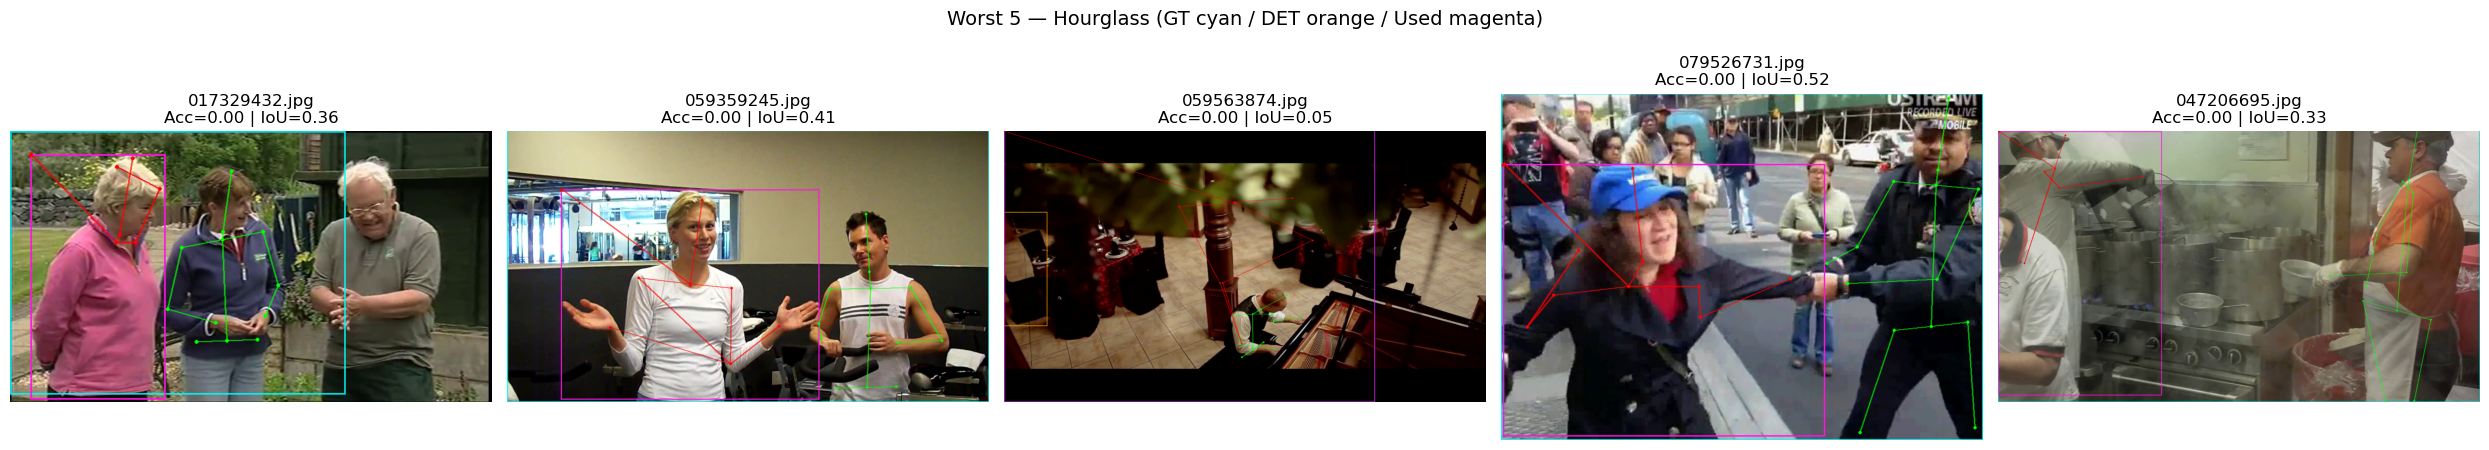

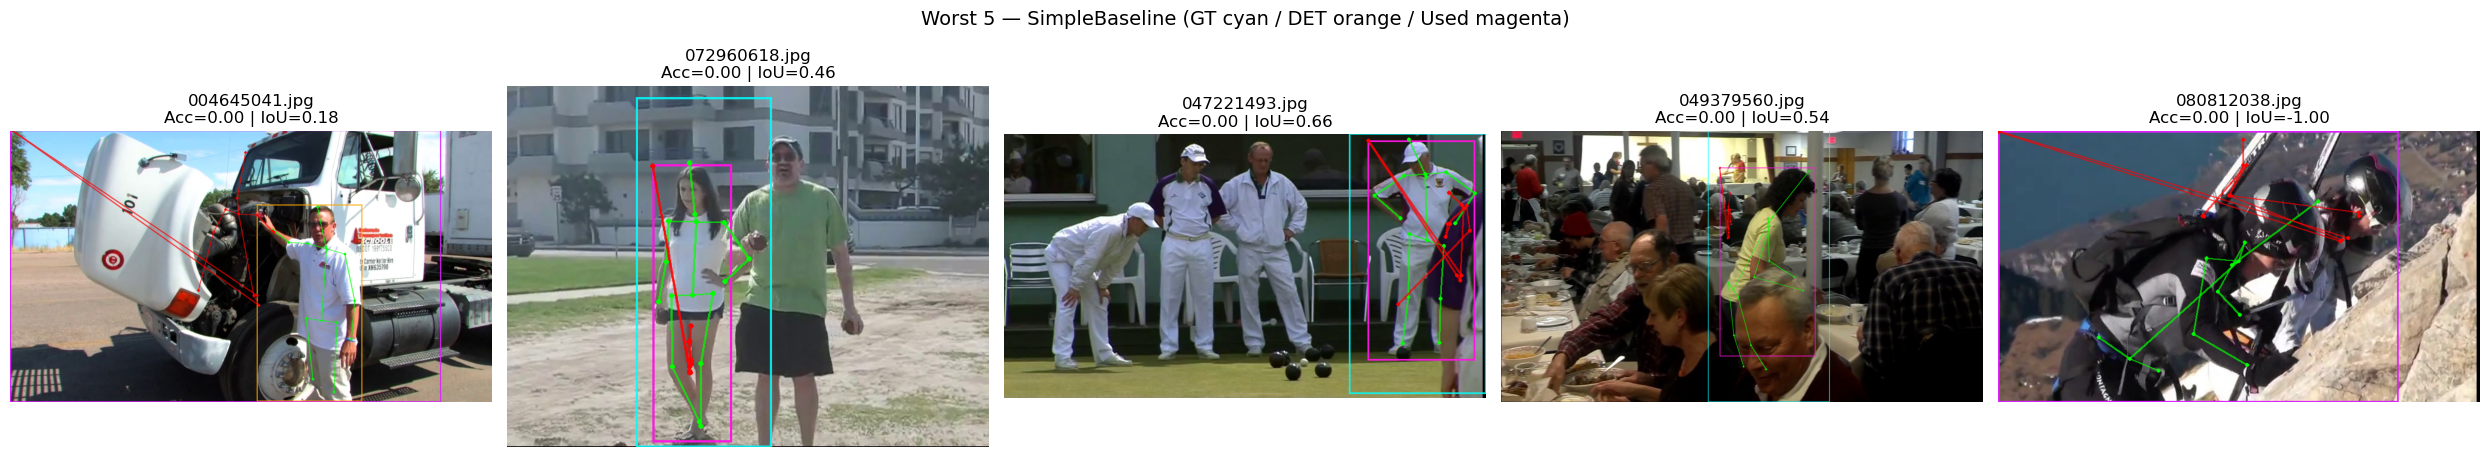

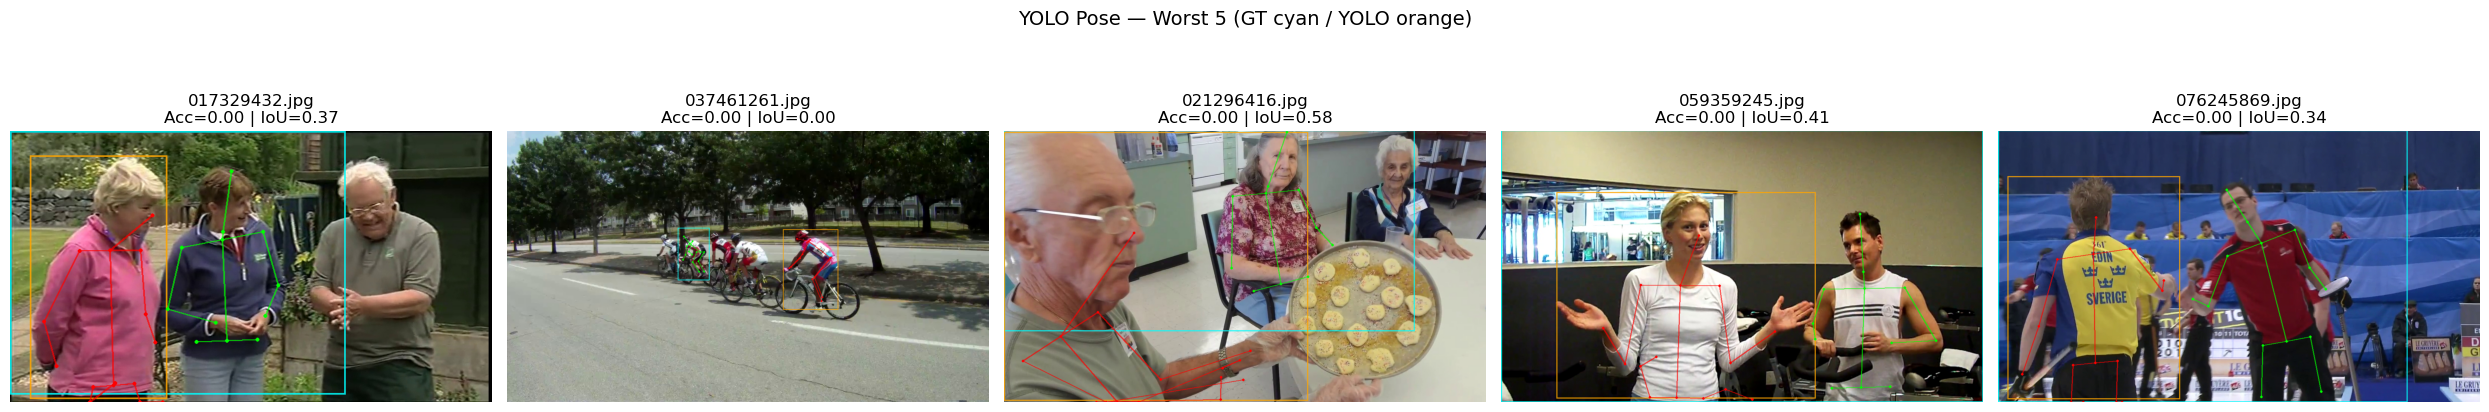

In [56]:
# ============================================
# 3개 모델 (Hourglass / SimpleBaseline / YOLOv8n-pose) 일괄 실행 스크립트
# ============================================
import os
from ultralytics import YOLO
import matplotlib.pyplot as plt

# --- 0) Detector 준비 (사람 박스용) ---
try:
    person_det
except NameError:
    person_det = YOLO("yolov8n.pt")  # COCO person detector

# --- 1) 평가 아이템 로드(선택: 일부만 먼저 보고 싶으면 [:100]) ---
items = _load_mpii_val_items(VAL_JSON, IMAGE_DIR)
print(f"[INFO] Loaded {len(items)} validation items")

# --- 2) SP(Hourglass/SimpleBaseline): IoU 기반 매칭 → crop → PCKh ---
results_sp, logs_sp = evaluate_pckh_sp_iou(
    models_sp=models_sp,
    detector=person_det,       # detector=None 도 가능 (GT bbox만 사용)
    json_path=VAL_JSON,
    image_dir=IMAGE_DIR,
    tau=0.5,
    iou_thr=0.2,               # GT-DET IoU가 0.2 미만이면 GT bbox로 fallback
    max_items=None,
    verbose_every=50
)

# --- 3) YOLOv8 Pose: GT bbox와 IoU 최대인 인물 선택 → PCKh ---
# dict에 들어있다면 꺼내고, 없다면 직접 모델 객체 전달
try:
    yolo_pose_model = models["YOLOv8n-pose"]
except Exception:
    # 이미 변수로 있다면 이 라인은 건너뜁니다.
    from ultralytics import YOLO as YOLOPose
    yolo_pose_model = YOLOPose("yolov8n-pose.pt").eval()

results_yolo, logs_yolo = evaluate_pckh_yolo_gtmatch(
    yolo_pose_model=yolo_pose_model,
    json_path=VAL_JSON,
    image_dir=IMAGE_DIR,
    tau=0.5,
    iou_thr=0.0,          # 필요하면 0.2~0.5로 올려서 GT와 충분히 겹칠 때만 평가
    max_items=None,
    verbose_every=50
)

# --- 4) 점수 출력 (간단 요약) ---
def _print_table(title, r):
    print(f"\n=== {title} | Mean PCKh@0.5: {r['pckh_mean']:.4f} ===")
    for j, v in enumerate(r["pckh_per_joint"]):
        print(f"  {MPII_NAMES[j]:>12s}: {v:.4f} (n={int(r['counts'][j])})")

for name, r in results_sp.items():
    _print_table(name, r)
_print_table("YOLOv8n-pose", results_yolo)

# --- 5) worst-5 시각화 (GT=초록, Pred=빨강, GT bbox=청록, DET bbox=주황, 사용 bbox(선택)=자홍) ---
show_worst_sp_with_bboxes(logs_sp, "Hourglass",      top_k=5)
show_worst_sp_with_bboxes(logs_sp, "SimpleBaseline", top_k=5)
show_yolo_worst5(logs_yolo, top_k=5)


## 회고
```
두 모델을 PCKh@0.5 로 평가를 한 경우
Hourglass 가 Simplebaseline 보다 더 높은 점수가 나왔다.(리셋하고 다시 실행하니 반대의 결과도 나왔다. 이해가 안된다)
YOLOv8n-pose 는 fine-tuning 없이 사용했는데 다른 모델보다 출력 속도도 빠르고 정확도도 가장 높았다.
다른 hugging face 모델을 사용해보려고 했으나 자잘한 오류를 해결하지 못하고 ultralytics 에서 YOLO 모델을 사용한 점이 아쉽다.
GT 근처로 박스 그려서 평가하니 성능이 향상했다. accuracy 가 낮은 경우는 detector 모델이 박스를 너무 크게 쳐서 여러 사람이 잡힌 경우였다.
다만, Simplebaseline 의 경우 다른 모델보다 성능 향상의 폭이 작은 점이 의아하다.
```